[ENG]

PROJECT 1 : ANALYSIS OF THESIS DEFENSES IN FRANCE FROM 1971 TO 2020

[FR]

PROJET 1 : ANALYSE DES SOUTENANCE DE THESES EN FRANCE DE 1971 à 2020 

In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import tqdm
import csv
import numpy as np
import calendar


In [2]:
# Loading csv file
df_phd_v2 = pd.read_csv(
    r"C:\Users\emmhu\OneDrive\Documents\E-LEARNING\DU DATA ANALYST\1_Manipulation et Prétraitement de données\Données\Theses Phd-Phdv2 (2e devoir)\PhD_v2.csv",
    delimiter=",",
    quotechar='"',
    low_memory=False,
    quoting=csv.QUOTE_ALL,
    on_bad_lines='skip',
    encoding='utf-8'
)
df_phd_v2.head()



,Auteur,Identifiant auteur,Titre,Directeur de these,Directeur de these (nom prenom),Identifiant directeur,Etablissement de soutenance,Identifiant etablissement,Discipline,Statut,Date de premiere inscription en doctorat,Date de soutenance,Year,Langue de la these,Identifiant de la these,Accessible en ligne,Publication dans theses.fr,Mise a jour dans theses.fr
0,Saeed Al marri,NaN,Le credit documentaire et l'onopposabilite des...,Philippe Delebecque,Delebecque Philippe,29561248,Paris 1,27361802,Driot prive,enCours,30-09-11,NaN,NaN,NaN,s69480,non,26-01-12,26-01-12
1,Andrea Ramazzotti,174423705,Application de la PGD a la resolution de probl...,"Jean-Claude Grandidier,Marianne Beringhier","Grandidier Jean-Claude,Beringhier Marianne","715,441,511","Chasseneuil-du-Poitou, Ecole nationale superie...",28024400,"Mecanique des solides, des materiaux, des stru...",enCours,01-10-12,NaN,NaN,NaN,s98826,non,22-11-13,22-11-13
2,OLIVIER BODENREIDER,NaN,Conception d'un outil informatique d'etude des...,Francois Kohler,Kohler Francois,57030758,Nancy 1,NaN,Medecine,soutenue,NaN,01-01-93,1993.0,fr,1993NAN19006,non,24-05-13,17-11-12
3,Emmanuel Porte,NaN,Socio-histoire des politiques publiques en mat...,Gilles Pollet,Pollet Gilles,na,Lyon 2,02640334X,Science politique,enCours,01-06-11,NaN,NaN,NaN,s88867,non,12-07-13,12-01-16
4,Arthur Devriendt,NaN,LES TECHNOLOGIES DE L'INFORMATION ET DE LA COM...,Gabriel Dupuy,Dupuy Gabriel,na,Paris 1,27361802,Geographie,enCours,07-12-09,NaN,NaN,NaN,s89663,non,13-07-13,12-07-13


In [3]:
# Understanding the data at hand : Summary of variables to identify their nature
df_phd_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 447644 entries, 0 to 447643
Data columns (total 18 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   Auteur                                    447644 non-null  object 
 1   Identifiant auteur                        317655 non-null  object 
 2   Titre                                     447635 non-null  object 
 3   Directeur de these                        447629 non-null  object 
 4   Directeur de these (nom prenom)           447629 non-null  object 
 5   Identifiant directeur                     447644 non-null  object 
 6   Etablissement de soutenance               447640 non-null  object 
 7   Identifiant etablissement                 430559 non-null  object 
 8   Discipline                                447639 non-null  object 
 9   Statut                                    447644 non-null  object 
 10  Date de premiere ins

In [4]:
print(df_phd_v2.columns)
df_phd_v2.describe(include='all')


Index(['Auteur', 'Identifiant auteur', 'Titre', 'Directeur de these',
       'Directeur de these (nom prenom)', 'Identifiant directeur',
       'Etablissement de soutenance', 'Identifiant etablissement',
       'Discipline', 'Statut', 'Date de premiere inscription en doctorat',
       'Date de soutenance', 'Year', 'Langue de la these',
       'Identifiant de la these', 'Accessible en ligne',
       'Publication dans theses.fr', 'Mise a jour dans theses.fr'],
      dtype='object')


,Auteur,Identifiant auteur,Titre,Directeur de these,Directeur de these (nom prenom),Identifiant directeur,Etablissement de soutenance,Identifiant etablissement,Discipline,Statut,Date de premiere inscription en doctorat,Date de soutenance,Year,Langue de la these,Identifiant de la these,Accessible en ligne,Publication dans theses.fr,Mise a jour dans theses.fr
count,447644,317655,447635,447629,447629,447644,447640,430559,447639,447644,63976,390898,390898.000000,383879,447644,447644,447644,447467
unique,430278,313774,446819,159020,159022,98907,567,572,24262,2,4009,3991,NaN,205,447572,2,2765,2633
top,Nicolas Martin,",",#NAME?,Directeur de these inconnu,Directeur de these inconnu,na,Paris 6,27787087,Medecine,soutenue,01-10-18,01-01-94,NaN,fr,s222831,non,24-05-13,07-07-20
freq,16,462,17,713,713,49172,21201,20926,25908,381315,1500,12991,NaN,334404,2,347341,205883,61840
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003.247845,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.845610,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1971.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN


In [5]:
# Identify the mininum and maximum year in the dataset
print(df_phd_v2["Year"].max())
print(df_phd_v2["Year"].min())


2020.0
1971.0


1. IDENTIFYING MISSING DATA

[ENG]

Produce a graph showing the distribution of missing data within the dataset.

[FR]

Réalisez un graphique pour représenter la répartition des données manquantes au sein du jeu de données.

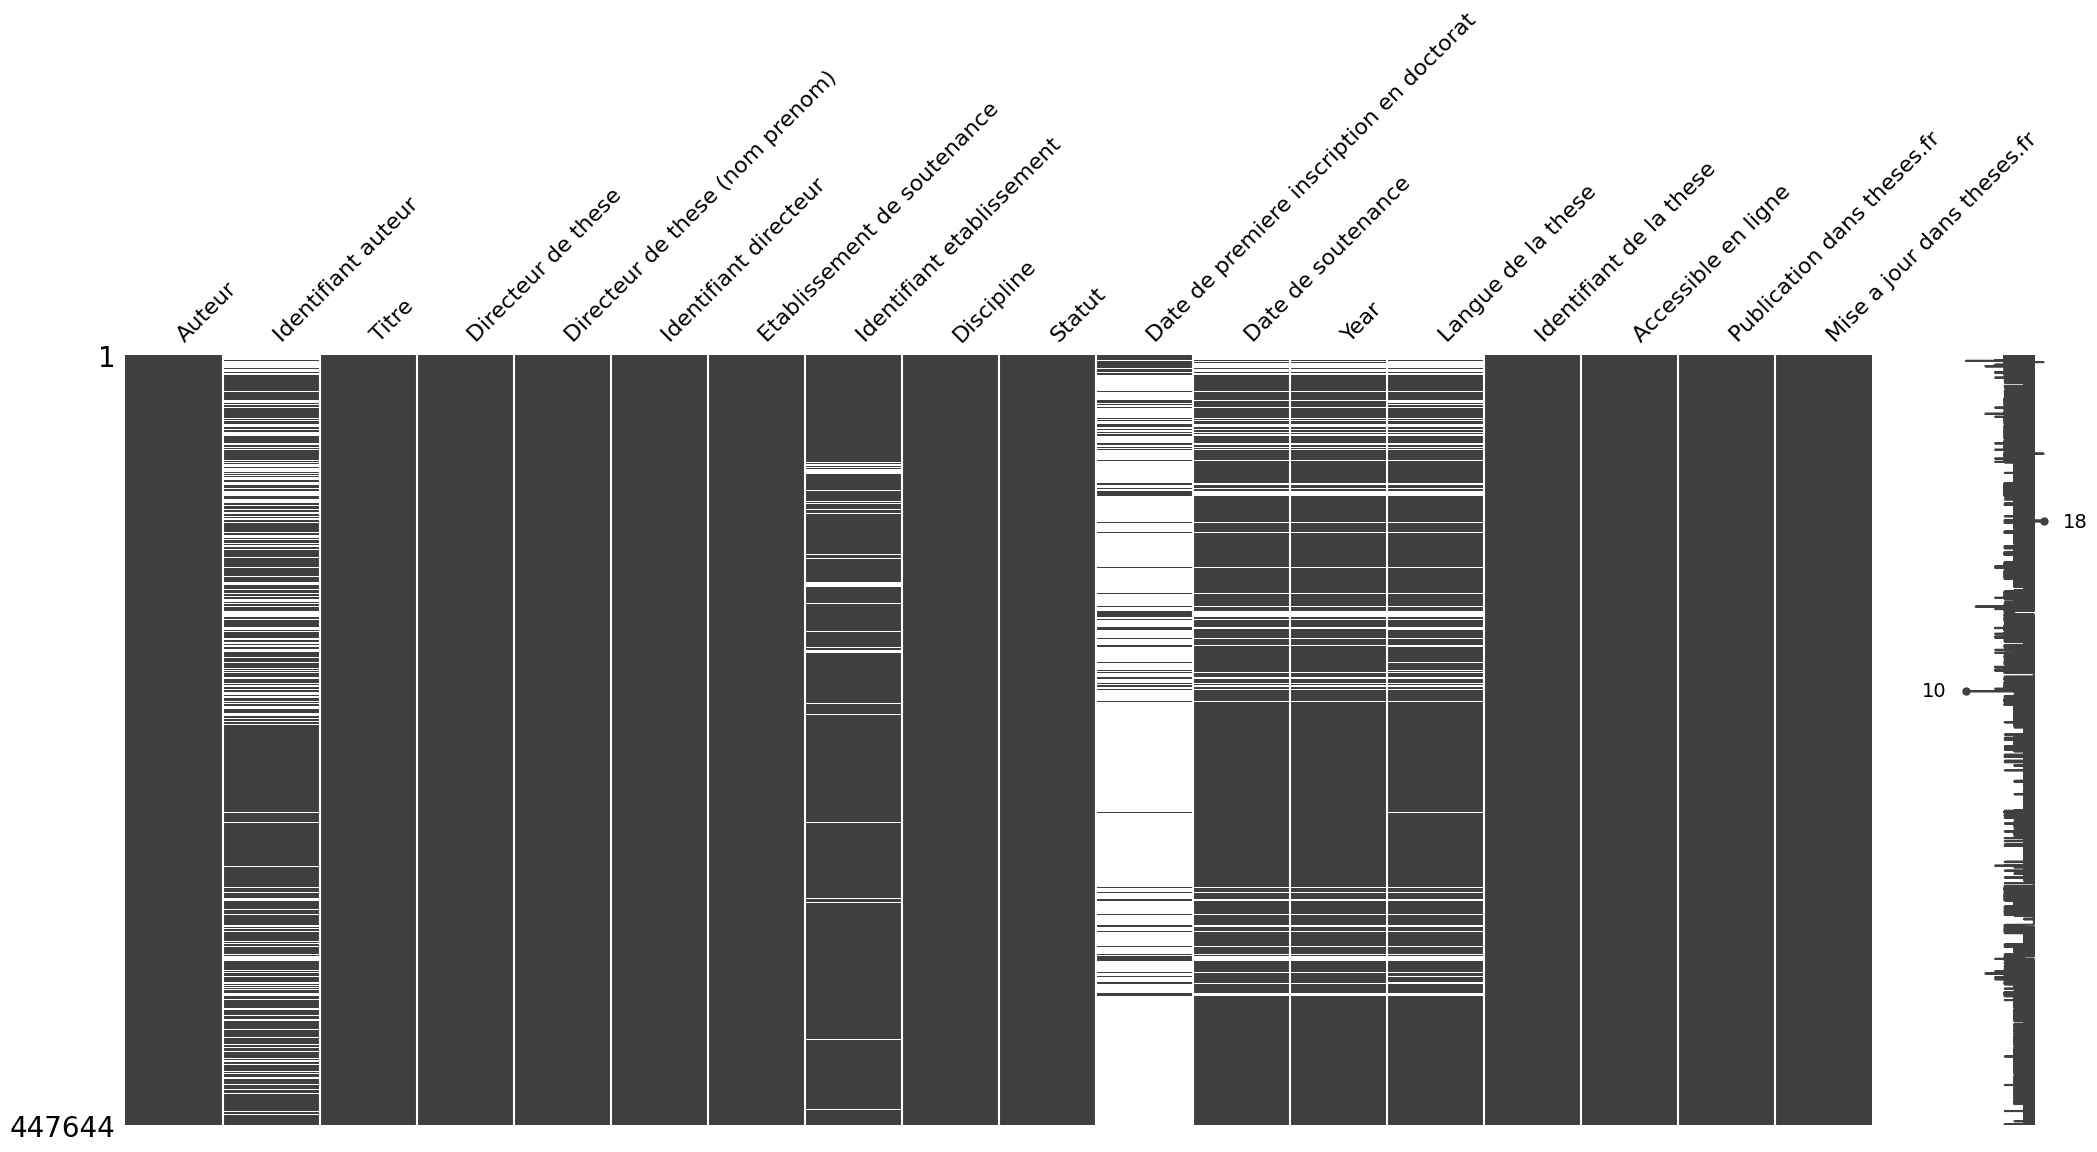

In [6]:
# Visualize the missingness summary

msno.matrix(df_phd_v2)
plt.show()

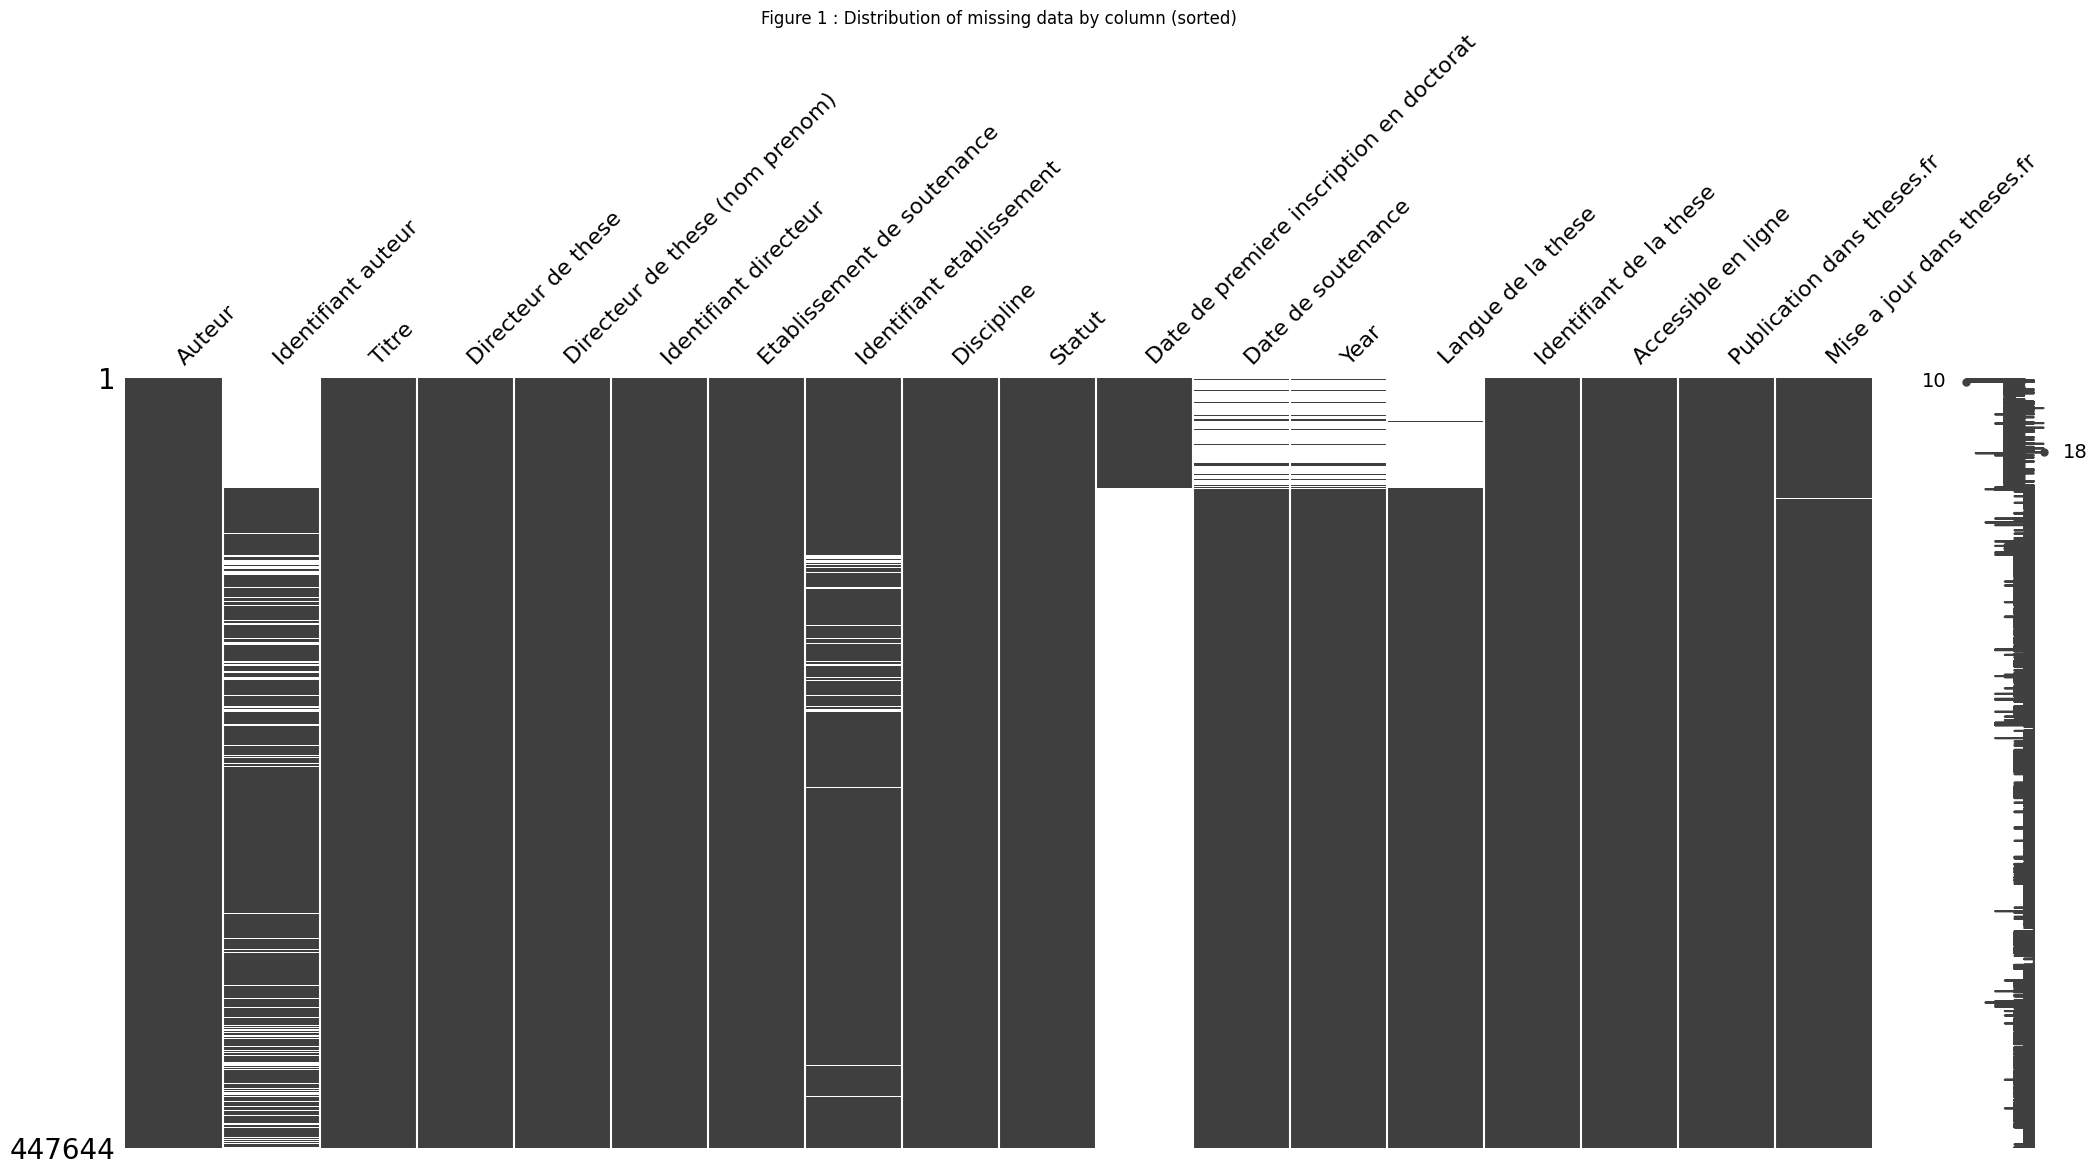

In [7]:
# Sort df_phd_v2 dataframe  on 'Date de premiere inscription en doctorat' column
sorted_values = df_phd_v2.sort_values('Date de premiere inscription en doctorat')

# Visualize the missingness summary of sorted
msno.matrix(sorted_values)
plt.title('Figure 1 : Distribution of missing data by column (sorted)')
plt.savefig('Figure1_Distribution_of_missing_data_by_column_(sorted).png', dpi=300)
plt.show() # MNAR

In [8]:
# Calculate the number of missing data globally
df_phd_missingness=df_phd_v2.isnull()
missing_values_sum=df_phd_missingness.sum()

print('Total missing values:\n',missing_values_sum)


Total missing values:
 Auteur                                           0
Identifiant auteur                          129989
Titre                                            9
Directeur de these                              15
Directeur de these (nom prenom)                 15
Identifiant directeur                            0
Etablissement de soutenance                      4
Identifiant etablissement                    17085
Discipline                                       5
Statut                                           0
Date de premiere inscription en doctorat    383668
Date de soutenance                           56746
Year                                         56746
Langue de la these                           63765
Identifiant de la these                          0
Accessible en ligne                              0
Publication dans theses.fr                       0
Mise a jour dans theses.fr                     177
dtype: int64


In [9]:
# Calculate the missing data percentage
(df_phd_v2.isna().mean() *100).round(2)

Auteur                                       0.00
Identifiant auteur                          29.04
Titre                                        0.00
Directeur de these                           0.00
Directeur de these (nom prenom)              0.00
Identifiant directeur                        0.00
Etablissement de soutenance                  0.00
Identifiant etablissement                    3.82
Discipline                                   0.00
Statut                                       0.00
Date de premiere inscription en doctorat    85.71
Date de soutenance                          12.68
Year                                        12.68
Langue de la these                          14.24
Identifiant de la these                      0.00
Accessible en ligne                          0.00
Publication dans theses.fr                   0.00
Mise a jour dans theses.fr                   0.04
dtype: float64

[ENG]

Make a heat map (the colour depends on the percentage of missing data), choosing ‘status’ as the ‘x’ variable: this contrasts the ‘ongoing’ and ‘defended’ levels. 
This contrasts the ‘in progress’ and ‘defended’ levels. It's up to you to choose a subset of variables on the ordinate that you feel is relevant to the analyses. Can you see any patterns in the missing data? Try to visualise them.

[FR] 
 
Faites une heat map (la couleur dépendant du pourcentage de données manquantes), en choisissant « statut » comme variable en « abscisse » : vous contrastez ainsi les niveaux 
« enCours » et « soutenue ». A vous de choisir en ordonnée un sous-ensemble de variables qui vous semblerait pertinent par rapport aux analyses. Observez-vous des régularités dans le caractère manquant des données ? Tâchez de les visualiser.

In [10]:
#Creating a sub dataframe with only the column the most concerned by missing data
df_missing_values= df_phd_v2[['Statut','Date de premiere inscription en doctorat','Date de soutenance','Year','Langue de la these','Identifiant auteur']]
df_missing_values.head()





,Statut,Date de premiere inscription en doctorat,Date de soutenance,Year,Langue de la these,Identifiant auteur
0,enCours,30-09-11,NaN,NaN,NaN,NaN
1,enCours,01-10-12,NaN,NaN,NaN,174423705
2,soutenue,NaN,01-01-93,1993.0,fr,NaN
3,enCours,01-06-11,NaN,NaN,NaN,NaN
4,enCours,07-12-09,NaN,NaN,NaN,NaN


In [11]:
# Calculate the quantity of missing data per status
missing_values_quantity=df_missing_values.isna().groupby(df_missing_values['Statut']).sum().transpose()

# Calculate the percentage of missing data per status
all_values=df_phd_v2['Statut'].value_counts()
missing_values_percent=((missing_values_quantity/all_values) * 100).round(2)

# Rename columns as "En cours" and "Soutenue" (thesis)
missing_values_percent.columns=['En cours', 'Soutenue']

#Display the dataframe with missing percentage
print(missing_values_percent)


                                          En cours  Soutenue
Statut                                        0.00      0.00
Date de premiere inscription en doctorat      3.55    100.00
Date de soutenance                           85.37      0.03
Year                                         85.37      0.03
Langue de la these                           95.94      0.03
Identifiant auteur                           99.66     16.75


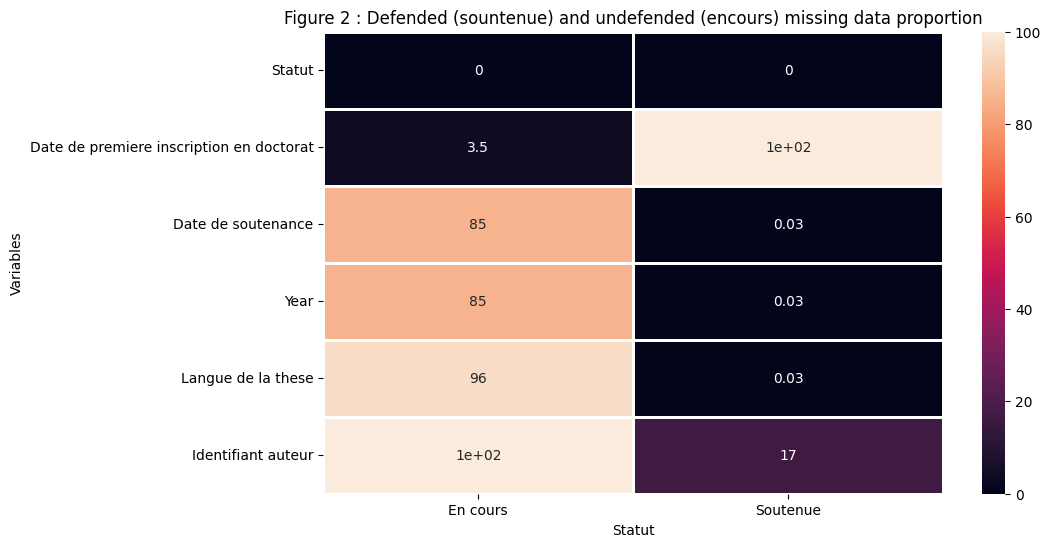

In [12]:
#Plot an heatmap of missing values with percentages to see correlation
plt.figure(figsize=(10,6))
sns.heatmap(missing_values_percent, annot= True, cbar= True, linewidth= 1)
plt.title('Figure 2 : Defended (sountenue) and undefended (encours) missing data proportion')
plt.xlabel('Statut')
plt.ylabel('Variables')

plt.savefig('Figure2_Defended_(sountenue)_and_undefended_(encours)_missing_data_proportion', dpi=300)
plt.show()

## Heatmap of Missing Data Proportions by Status

We created a heatmap where:
- **X-axis** represents the **Status** ("En cours" = In Progress, "Soutenue" = Defended).
- **Y-axis** shows a selection of relevant variables:
  - Statut
  - Date de première inscription en doctorat
  - Date de soutenance
  - Year
  - Langue de la thèse
  - Identifiant auteur

The colour intensity depends on the **percentage of missing data** for each combination of variable and status.

---

## Observations and Patterns:

- **'Statut'** is complete (0% missing) for both "En cours" and "Soutenue".
- **'Date de première inscription en doctorat'**:
  - Nearly **100% missing** for defended theses ("Soutenue").
  - Very few missing values (~3.5%) for theses in progress ("En cours").
- **'Date de soutenance'** and **'Year'**:
  - **Around 85% missing** for "En cours" (which makes sense because these theses are not yet defended).
  - Almost no missing data for defended theses.
- **'Langue de la thèse'**:
  - A relatively high proportion (~96%) missing for "En cours".
  - Very low missing rate for defended theses.
- **'Identifiant auteur'**:
  - Close to **100% missing** for "En cours".
  - About **17% missing** for defended theses.

---

## Interpretation:

Clear patterns emerge:
- Variables related to **thesis completion** (such as defense date and year) are naturally missing for theses still "En cours".
- **Administrative data** (like language and author ID) tend to be incomplete for theses that are not yet defended.
- There is a **logical relationship** between the **start date** of the thesis (**date de première inscription en doctorat**) and the **defense date** (**date de soutenance**).

### How to explain the pattern between 'date de première inscription en doctorat' ('start date') and 'date de soutenance' ('defense date') :

When a thesis is defended ("Soutenue"):
- Both the **start date** and the **defense date** must be documented for official graduation records.
- This explains why, when the **defense date** is known, the **start date** is usually also available.

When a thesis is still ongoing ("En cours"):
- The **defense date** is naturally missing because the thesis is not yet completed.
- In some cases, the **start date** might also be missing due to incomplete enrollment records, administrative delays, or students who have interrupted or extended their studies.

Thus, **the presence or absence** of both dates reflects the **administrative progression** and **documentation quality** depending on whether the thesis has been defended or is still underway.

Visualizing missing data this way helps anticipate potential biases or data cleaning needs before moving forward with deeper analyses.


In [13]:
# Converting 'Date de soutenance' column to Datetime format
df_phd_v2['Date de soutenance'] = pd.to_datetime(df_phd_v2['Date de soutenance'], errors='coerce')

C:\Users\emmhu\AppData\Local\Temp\ipykernel_25512\3233421920.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_phd_v2['Date de soutenance'] = pd.to_datetime(df_phd_v2['Date de soutenance'], errors='coerce')


In [14]:
# Verify NaN values after converting the column
missing_dates = df_phd_v2[df_phd_v2['Date de soutenance'].isna()]
if not missing_dates.empty:
    print("Warning : some dates are not converted :", missing_dates)

0             Saeed Al marri                NaN   
1          Andrea Ramazzotti          174423705   
3             Emmanuel Porte                NaN   
4           Arthur Devriendt                NaN   
11          Vladimir Arneuve                NaN   
...                      ...                ...   
447637          Lucas Mosser                NaN   
447638      Jocelyn Poncelet                NaN   
447639          Emir Roumili                NaN   
447640         Nesrine Salah                NaN   
447641  Ghulam sakhi Shokouh                NaN   

                                                    Titre  \
0       Le credit documentaire et l'onopposabilite des...   
1       Application de la PGD a la resolution de probl...   
3       Socio-histoire des politiques publiques en mat...   
4       LES TECHNOLOGIES DE L'INFORMATION ET DE LA COM...   
11            Droit de la consommation et responsabilites   
...                                                   ...   
447637  Bet

2. DETECTING AN ISSUE IN THE DATASET

[ENG]

Represent the distribution of the month of defense for the entire dataset, over the period 1984-2018 (Why the choice to stop in 2018?). You need to find the control lines so that the months are ordered correctly (January on the left, December on the right). This is a simple distribution. To do this, you need to convert the variable associated with the date into a format that can be easily processed. You need to use the command that automatically extracts the month from the date. How do you interpret the result for the January exams?

[FR]
 
Représentez la distribution du mois de soutenance pour l’intégralité du jeu de données, sur la période 1984-2018 (Pourquoi le choix de s’arrêter en 2018 ?). Vous devez trouver les lignes de commandes pour que les mois soient ordonnés dans le bon ordre (janvier à gauche, décembre à droite). Il s’agit ici d’une simple distribution. Pour ce faire, vous devrez convertir la variable associée à la date dans un format qui pourra facilement être traité. Vous devez utiliser la commande qui permet d’extraire automatiquement le mois à partir de la date. Comment interprétez-vous le résultat relatif aux soutenances du mois de janvier ?

In [15]:
# Creating a sub dataframe filtering data between 1984 and 2018
df_phd_8418 = df_phd_v2[(df_phd_v2['Year'] >= 1984) & (df_phd_v2['Year'] <= 2018)]

In [16]:
# Extract the month from the 'Date de soutenance' column
df_phd_8418['Month'] = df_phd_8418['Date de soutenance'].dt.month

df_phd_8418.head()

C:\Users\emmhu\AppData\Local\Temp\ipykernel_25512\146422417.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_phd_8418['Month'] = df_phd_8418['Date de soutenance'].dt.month


,Auteur,Identifiant auteur,Titre,Directeur de these,Directeur de these (nom prenom),Identifiant directeur,Etablissement de soutenance,Identifiant etablissement,Discipline,Statut,Date de premiere inscription en doctorat,Date de soutenance,Year,Langue de la these,Identifiant de la these,Accessible en ligne,Publication dans theses.fr,Mise a jour dans theses.fr,Month
2,OLIVIER BODENREIDER,NaN,Conception d'un outil informatique d'etude des...,Francois Kohler,Kohler Francois,57030758,Nancy 1,NaN,Medecine,soutenue,NaN,1993-01-01,1993.0,fr,1993NAN19006,non,24-05-13,17-11-12,1
5,Elmantsr Briak,NaN,Integration forcee de l'afrique subsaharienne ...,Edmond Jouve,Jouve Edmond,26941848,Paris 5,26404788,Science politique,enCours,01-12-02,2008-11-24,2008.0,NaN,s6336,non,26-09-11,16-11-11,11
6,Jae-hyun Park,NaN,Execution des decisions de justice condamnant ...,Pierre Comte,Comte Pierre,na,Saint Etienne,28209966,Droit public,enCours,01-02-02,2005-01-07,2005.0,NaN,s8305,non,26-09-11,02-02-12,1
7,Laurent david Benoiton,NaN,Les effets des arrets de la Cour europeenne de...,Laurent Sermet,Sermet Laurent,34508287,La Reunion,26404451,Droit public,enCours,01-10-03,2009-08-12,2009.0,NaN,s11271,non,26-09-11,26-04-12,8
8,Jennifer Guiraud (McKELLIPS),NaN,L'autobiographie sans frontieres : espace et d...,Anne-Emmanuelle Berger,Berger Anne-Emmanuelle,32574088,Paris 8,26403552,Etudes de genre,enCours,01-11-03,2013-10-01,2013.0,NaN,s11354,non,26-09-11,04-04-16,10


In [17]:
# Converting month column into a new month name column to get a better display

df_phd_8418['Month_Name'] = df_phd_8418['Date de soutenance'].dt.strftime('%B')

df_phd_8418.head()

C:\Users\emmhu\AppData\Local\Temp\ipykernel_25512\2048585954.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_phd_8418['Month_Name'] = df_phd_8418['Date de soutenance'].dt.strftime('%B')


,Auteur,Identifiant auteur,Titre,Directeur de these,Directeur de these (nom prenom),Identifiant directeur,Etablissement de soutenance,Identifiant etablissement,Discipline,Statut,Date de premiere inscription en doctorat,Date de soutenance,Year,Langue de la these,Identifiant de la these,Accessible en ligne,Publication dans theses.fr,Mise a jour dans theses.fr,Month,Month_Name
2,OLIVIER BODENREIDER,NaN,Conception d'un outil informatique d'etude des...,Francois Kohler,Kohler Francois,57030758,Nancy 1,NaN,Medecine,soutenue,NaN,1993-01-01,1993.0,fr,1993NAN19006,non,24-05-13,17-11-12,1,January
5,Elmantsr Briak,NaN,Integration forcee de l'afrique subsaharienne ...,Edmond Jouve,Jouve Edmond,26941848,Paris 5,26404788,Science politique,enCours,01-12-02,2008-11-24,2008.0,NaN,s6336,non,26-09-11,16-11-11,11,November
6,Jae-hyun Park,NaN,Execution des decisions de justice condamnant ...,Pierre Comte,Comte Pierre,na,Saint Etienne,28209966,Droit public,enCours,01-02-02,2005-01-07,2005.0,NaN,s8305,non,26-09-11,02-02-12,1,January
7,Laurent david Benoiton,NaN,Les effets des arrets de la Cour europeenne de...,Laurent Sermet,Sermet Laurent,34508287,La Reunion,26404451,Droit public,enCours,01-10-03,2009-08-12,2009.0,NaN,s11271,non,26-09-11,26-04-12,8,August
8,Jennifer Guiraud (McKELLIPS),NaN,L'autobiographie sans frontieres : espace et d...,Anne-Emmanuelle Berger,Berger Anne-Emmanuelle,32574088,Paris 8,26403552,Etudes de genre,enCours,01-11-03,2013-10-01,2013.0,NaN,s11354,non,26-09-11,04-04-16,10,October


In [18]:
# Natural months order
months_order = list(calendar.month_name[1:])  # ['January', ..., 'December']


# Calculate counts for each month
month_counts = df_phd_8418['Month_Name'].value_counts().reindex(months_order)

month_counts

Month_Name
January      286770
February       4411
March          6037
April          4874
May            6114
June           9224
July           4605
August         3490
September     11619
October       10067
November      15299
December      16599
Name: count, dtype: int64

In [19]:
# Convert 'Month_Name' into a sorted categorial variable
df_phd_8418['Month_Name'] = pd.Categorical(df_phd_8418['Month_Name'], categories=months_order, ordered=True)

C:\Users\emmhu\AppData\Local\Temp\ipykernel_25512\3429692067.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_phd_8418['Month_Name'] = pd.Categorical(df_phd_8418['Month_Name'], categories=months_order, ordered=True)


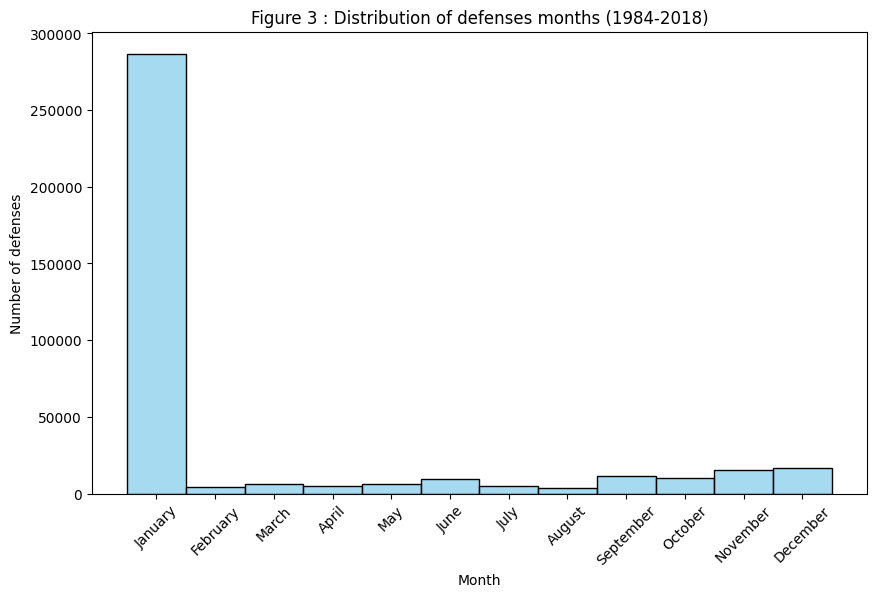

In [20]:
# Create an histogram concerning defenses' months

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_phd_8418, 
    x='Month_Name', 
    bins=12, 
    color='skyblue'
    )
plt.xlabel('Month')
plt.ylabel('Number of defenses')
plt.title('Figure 3 : Distribution of defenses months (1984-2018)')
plt.xticks(rotation=45)
plt.savefig('Figure3_Distribution_of_defenses_months_(1984-2018).png',dpi=300)
plt.show()


## Interpretation of the Distribution of Defenses by Month (1984–2018)

The bar plot shows the distribution of thesis defenses by month.  
One striking feature is the **very large peak in January** compared to all other months.

---

## How to interpret the result for January?

The extremely high number of defenses recorded in **January** suggests an **administrative effect** rather than a real academic pattern:

- In many cases, **the official defense date is automatically recorded as January 1st** when the actual defense date is missing or not properly entered in the system.
- As a result, January absorbs a massive number of defenses that were probably completed earlier but whose precise dates were lost or never recorded.

Thus, the peak for January is **an artifact of missing or incomplete data**, not a reflection of actual defense activity during that month.

---

## Conclusion

The huge January peak must be **interpreted with caution**.  
For realistic monthly analysis of defenses, it would be better to **exclude January** or **treat it separately**, recognizing that it mostly reflects **data recording practices** rather than real academic scheduling.


[ENG]

The next mission will involve filtering and aggregation (group.by), and what we call a facet-wrap. Seaborn's Facetgrid function can be useful in Python. First of all, represent the distribution of the month of defense for each year, from 2005 to 2018. To do this, you'll need to follow a group.by logic on two variables (the month and the year), then a count. Only then will you have the intermediate database that will allow you to calculate averages and standard deviations. Then find a solution so that only the proportion of submissions in a given month is represented, for a given year. To start with, you will need one graph per year, i.e. fourteen graphs.

[FR]

La prochaine mission mobilisera les logiques de filtre et d’aggrégation (group.by), et ce que l’on nomme un facet-wrap. La fonction Facetgrid de seaborn peut être utile sur Python. Tout d'abord, représentez en premier lieu la distribution du mois de soutenance pour chaque année, de 2005 à 2018. Pour réaliser ce travail, vous devrez suivre une logique de group.by sur deux variables (le mois et l’année), puis un count. Alors seulement vous aurez la base de données intermédiaire qui vous permettra de calculer des moyennes et des écarts-type. Trouvez ensuite une solution pour que seule la proportion des soutenances d’un mois donné soit représentée, pour une année donnée. Il faut donc pour commencer, un graphique par année, soit quatorze graphiques.

In [21]:
# Extract the year from the 'Date de soutenance' column
df_phd_8418['Année'] = df_phd_8418['Date de soutenance'].dt.year

df_phd_8418.head()

C:\Users\emmhu\AppData\Local\Temp\ipykernel_25512\1973209281.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_phd_8418['Année'] = df_phd_8418['Date de soutenance'].dt.year


,Auteur,Identifiant auteur,Titre,Directeur de these,Directeur de these (nom prenom),Identifiant directeur,Etablissement de soutenance,Identifiant etablissement,Discipline,Statut,...,Date de soutenance,Year,Langue de la these,Identifiant de la these,Accessible en ligne,Publication dans theses.fr,Mise a jour dans theses.fr,Month,Month_Name,Année
2,OLIVIER BODENREIDER,NaN,Conception d'un outil informatique d'etude des...,Francois Kohler,Kohler Francois,57030758,Nancy 1,NaN,Medecine,soutenue,...,1993-01-01,1993.0,fr,1993NAN19006,non,24-05-13,17-11-12,1,January,1993
5,Elmantsr Briak,NaN,Integration forcee de l'afrique subsaharienne ...,Edmond Jouve,Jouve Edmond,26941848,Paris 5,26404788,Science politique,enCours,...,2008-11-24,2008.0,NaN,s6336,non,26-09-11,16-11-11,11,November,2008
6,Jae-hyun Park,NaN,Execution des decisions de justice condamnant ...,Pierre Comte,Comte Pierre,na,Saint Etienne,28209966,Droit public,enCours,...,2005-01-07,2005.0,NaN,s8305,non,26-09-11,02-02-12,1,January,2005
7,Laurent david Benoiton,NaN,Les effets des arrets de la Cour europeenne de...,Laurent Sermet,Sermet Laurent,34508287,La Reunion,26404451,Droit public,enCours,...,2009-08-12,2009.0,NaN,s11271,non,26-09-11,26-04-12,8,August,2009
8,Jennifer Guiraud (McKELLIPS),NaN,L'autobiographie sans frontieres : espace et d...,Anne-Emmanuelle Berger,Berger Anne-Emmanuelle,32574088,Paris 8,26403552,Etudes de genre,enCours,...,2013-10-01,2013.0,NaN,s11354,non,26-09-11,04-04-16,10,October,2013


In [22]:
# Creating a sub dataframe filtering data between 2005 and 2018
df_phd_0518 = df_phd_8418[(df_phd_8418["Year"] >= 2005) & (df_phd_8418["Year"] <= 2018)]


In [23]:
# Filtering and Aggregating  to get the quantity of soutenance by 'Month' and 'Year' using 'Month' and 'Année' columns.
# Use groupby() and select a column without missing data to make a count
nb_defenses_month_year = df_phd_0518.groupby(["Month_Name", "Année"])["Identifiant de la these"].count().reset_index()
nb_defenses_month_year.rename(columns={"Identifiant de la these": "Nb_Defenses"}, inplace=True)

print(nb_defenses_month_year)


    Month_Name  Année  Nb_Defenses
0      January   2005        10526
1      January   2006        10889
2      January   2007        11355
3      January   2008        10744
4      January   2009         9693
..         ...    ...          ...
163   December   2014         1721
164   December   2015         1712
165   December   2016         2036
166   December   2017         2288
167   December   2018         2357

[168 rows x 3 columns]


C:\Users\emmhu\AppData\Local\Temp\ipykernel_25512\803520139.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nb_defenses_month_year = df_phd_0518.groupby(["Month_Name", "Année"])["Identifiant de la these"].count().reset_index()


In [24]:
# Convert 'Month_Name' to a categorical type with a specified order
nb_defenses_month_year["Month_Name"] = pd.Categorical(
    nb_defenses_month_year["Month_Name"],
    categories=months_order,
    ordered=True
)


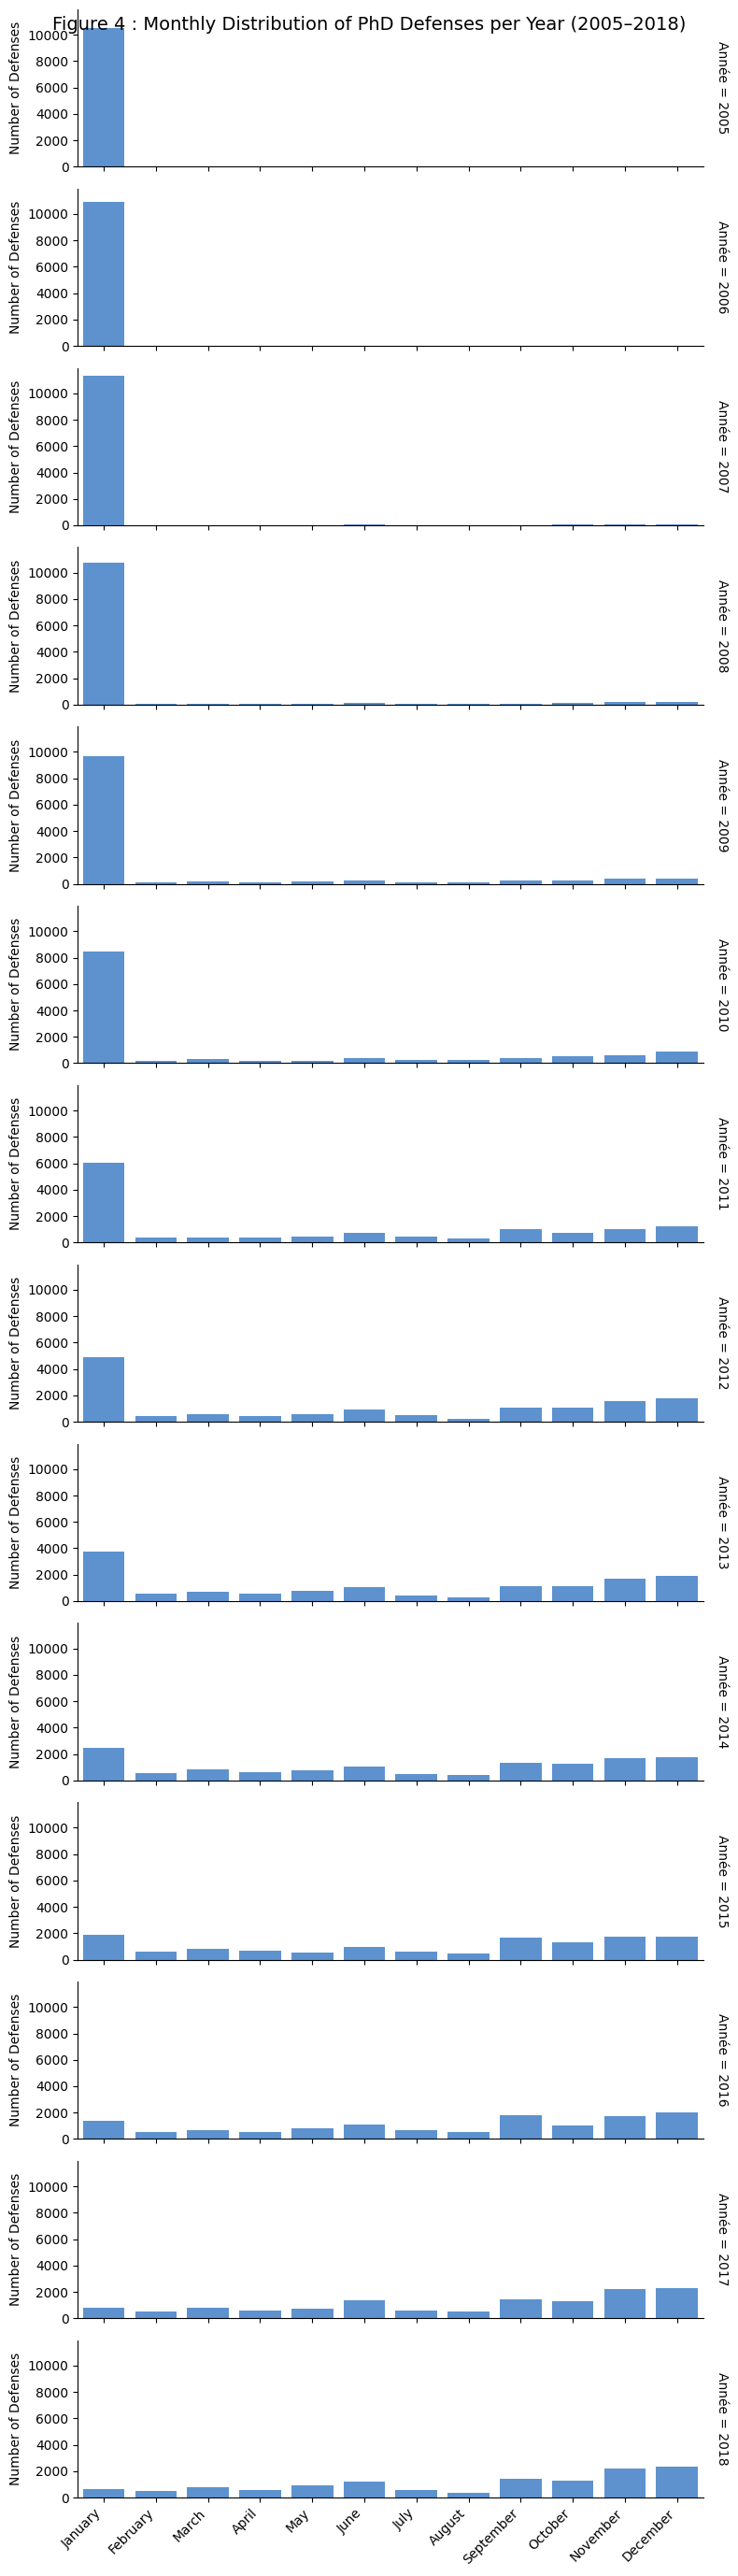

In [25]:
# Create a FacetGrid
g = sns.FacetGrid(
    nb_defenses_month_year,
    row="Année",
    row_order=sorted(nb_defenses_month_year['Année'].unique()),
    height=2,
    aspect=4,
    margin_titles=True
)


g.map(sns.barplot, "Month_Name", "Nb_Defenses", order=months_order, color="#4A90E2")  # Barplot on each row

g.set_axis_labels("", "Number of Defenses")  # Labels des axes

# Rotation and month names on each X-axis
for ax in g.axes.flat:
    ax.set_xticks(range(12))
    ax.set_xticklabels(months_order, rotation=45, ha='right')

# Save and display
plt.subplots_adjust(top=0.95)
g.fig.suptitle("Figure 4 : Monthly Distribution of PhD Defenses per Year (2005–2018)", fontsize=14)
plt.tight_layout()
plt.savefig('Figure4_Defenses_per_year.png', dpi=300)
plt.show()


[ENG]

Compile all the years to produce a single graph with a standard error.

[FR]

Compilez toutes les années pour ne produire qu’un seul et unique graphique, avec une erreur-type.

In [26]:
# Renaming 'Nb_Defenses' column to its genuine name 'Identifiant de la these'
nb_defenses_month_year.rename(columns={"Nb_Defenses": "Identifiant de la these"}, inplace=True)

In [27]:
# Creating a sub dataframe calculating the mean and std by month from 2005-2018
df_monthly_stats= nb_defenses_month_year.groupby('Month_Name')['Identifiant de la these'].agg(['mean','std']).reset_index()
df_monthly_stats

C:\Users\emmhu\AppData\Local\Temp\ipykernel_25512\1516574479.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_monthly_stats= nb_defenses_month_year.groupby('Month_Name')['Identifiant de la these'].agg(['mean','std']).reset_index()


,Month_Name,mean,std
0,January,5968.500000,4186.701010
1,February,314.571429,242.615148
2,March,430.357143,334.535868
3,April,347.571429,267.481621
4,May,435.714286,347.676337
5,June,657.571429,505.981258
6,July,328.071429,247.023656
7,August,248.785714,195.968278
8,September,828.357143,669.716887
9,October,718.142857,530.201102


In [28]:
df_monthly_stats['Month_Name'].dtype

CategoricalDtype(categories=['January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November',
                  'December'],
, ordered=True, categories_dtype=object)

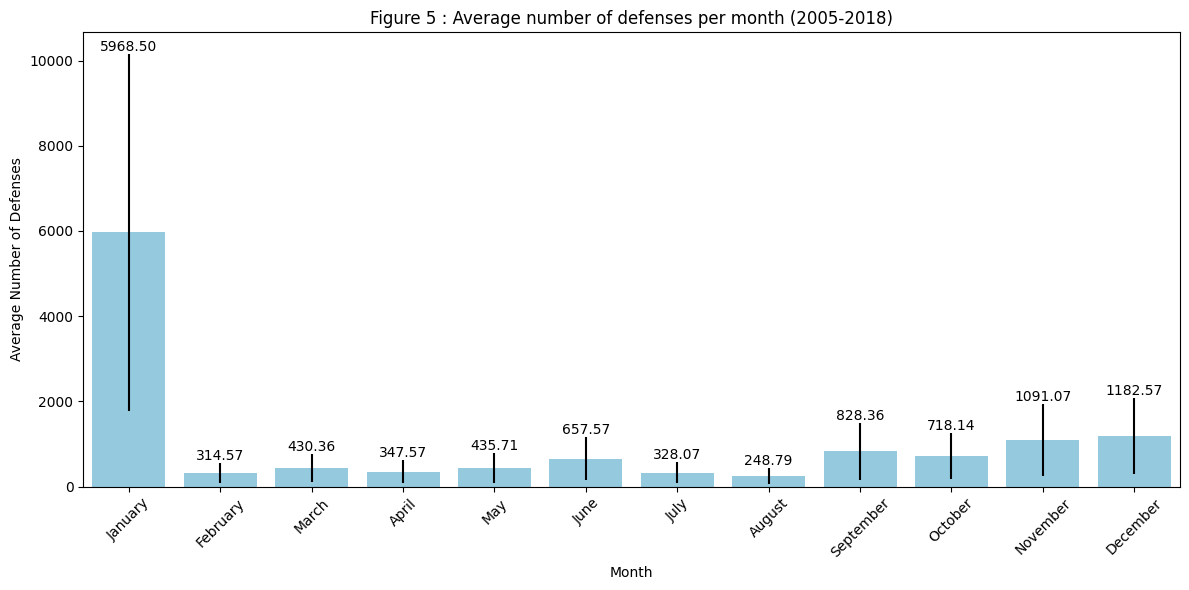

In [29]:
# Create a barplot  of the average number of defenses per month from 2005 to 2018. Add an error bar.
plt.figure(figsize= (12,6))
sns.barplot(data=df_monthly_stats, x='Month_Name', y='mean', order=months_order, 
            yerr=df_monthly_stats['std'], capsize=0.1, color='Skyblue')
for i, row in df_monthly_stats.iterrows(): # Annotate each bar
    plt.text(i, row['mean'] + row['std'] + 1, f"{row['mean']:.2f}", ha='center', va='bottom')
plt.title('Figure 5 : Average number of defenses per month (2005-2018)')    
plt.xlabel('Month')
plt.ylabel('Average Number of Defenses')
plt.xticks(rotation=45)
plt.savefig('Figure5_Average_Number_of_Defenses_per_Month_(2005-2018).png', dpi=300)
plt.tight_layout()
plt.show()

## Average Number of Defenses per Month (2005–2018)

The bar plot shows the **average number of thesis defenses** for each month, based on data from 2005 to 2018.  
Error bars represent the **standard deviation**, reflecting the variability of defenses across years.

---

## Key Observations:

- **January** again shows a **very large average** compared to the other months, with a mean of around **5968 defenses**.
- This January peak is accompanied by a **very large standard deviation**, indicating high variability from year to year.
- Other months have much lower and more stable averages, typically between **250 and 1200 defenses**:
  - **November** and **December** have relatively higher averages (~1091 and ~1182 defenses, respectively).
  - **February**, **March**, **April**, **May**, and **July** show lower defense activity.

---

## Interpretation:

- The unusually high January average, combined with its large variability, **confirms previous findings**:  
  - **Many theses without recorded defense dates are administratively assigned to January**, inflating the numbers artificially.
- For the remaining months:
  - The defense activity is relatively consistent across the years, with slight increases toward the **end of the calendar year** (November and December).
  - Peaks in November and December could correspond to **academic or administrative deadlines** (e.g., completion before the end of the academic cycle or fiscal year).

---

## Conclusion:

The January data should be interpreted with **caution**, as it mainly reflects **administrative artifacts** rather than real thesis defense scheduling.  
For a more accurate analysis of defense seasonality, it would be better to **exclude January** or **analyze it separately** from other months.



[ENG]

How has the proportion of applications submitted on the first of January changed over the years? Draw a graph.
How do you interpret this change?

[FR]

Comment la proportion des soutenances au premier janvier a-t-elle évolué au fil des ans ? Réalisez un graphique.
Comment interprétez-vous cette évolution ?

In [30]:
# Filter data for January defenses
df_january_defenses = df_phd_0518[(df_phd_0518['Month_Name'] == 'January')]
                              

# Calculate the number of January defenses per year
january_defenses_count = df_january_defenses['Year'].value_counts().sort_index()

january_defenses_count


Year
2005.0    10526
2006.0    10889
2007.0    11355
2008.0    10744
2009.0     9693
2010.0     8458
2011.0     6054
2012.0     4898
2013.0     3762
2014.0     2454
2015.0     1872
2016.0     1409
2017.0      805
2018.0      640
Name: count, dtype: int64

In [31]:
# Calculate the total number of defenses per year
total_defenses = df_phd_0518['Year'].value_counts().sort_index()

# Print total defenses to check if it's calculated correctly
print("Total defenses per year:")
print(total_defenses)


Total defenses per year:
Year
2005.0    10562
2006.0    10975
2007.0    11697
2008.0    11854
2009.0    12033
2010.0    12516
2011.0    13110
2012.0    13985
2013.0    13868
2014.0    13202
2015.0    13023
2016.0    12965
2017.0    13123
2018.0    12805
Name: count, dtype: int64


In [32]:
# Calculate the proportion of defenses in January per year
proportion_january = ((january_defenses_count / total_defenses) * 100).round(2)

print(proportion_january )

Year
2005.0    99.66
2006.0    99.22
2007.0    97.08
2008.0    90.64
2009.0    80.55
2010.0    67.58
2011.0    46.18
2012.0    35.02
2013.0    27.13
2014.0    18.59
2015.0    14.37
2016.0    10.87
2017.0     6.13
2018.0     5.00
Name: count, dtype: float64


In [33]:
# Fill missing years with zero (for years with no January defenses)
all_years = pd.Series(0, index=range(2005, 2019))
proportion_january = proportion_january.add(all_years, fill_value=0)

# Print the proportion to verify results
print("Proportion of January defenses per year:")
print(proportion_january)

Proportion of January defenses per year:
Year
2005.0    99.66
2006.0    99.22
2007.0    97.08
2008.0    90.64
2009.0    80.55
2010.0    67.58
2011.0    46.18
2012.0    35.02
2013.0    27.13
2014.0    18.59
2015.0    14.37
2016.0    10.87
2017.0     6.13
2018.0     5.00
dtype: float64


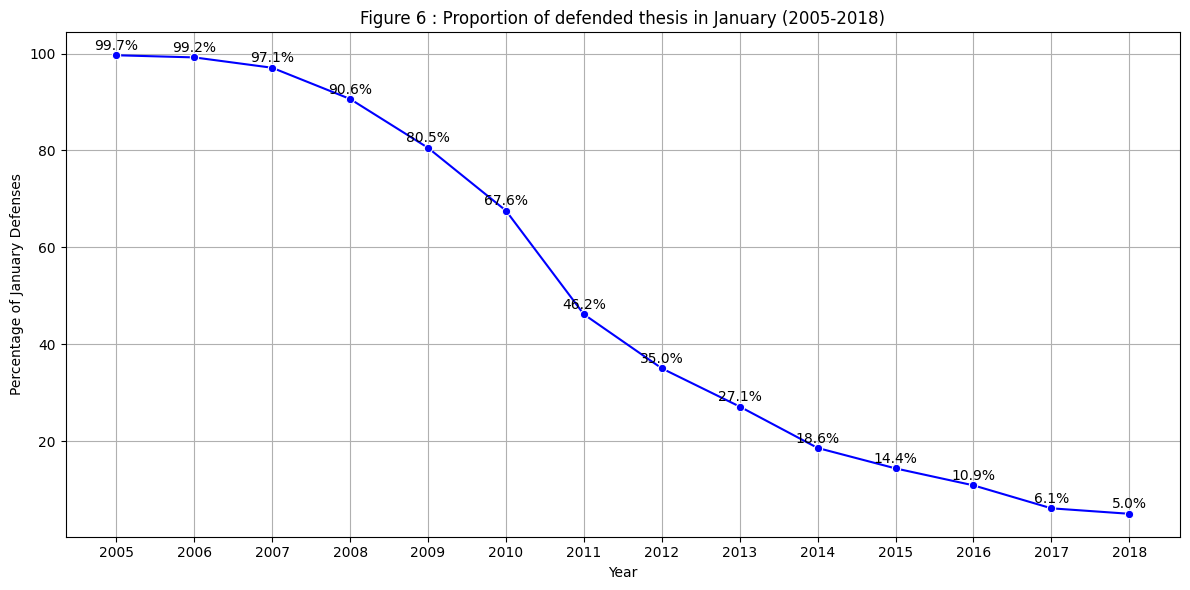

In [34]:
# Plotting the results
plt.figure(figsize=(12, 6))
sns.lineplot(x=proportion_january.index, y=proportion_january.values, marker='o', color='b')

# Customizing the plot
plt.title('Figure 6 : Proportion of defended thesis in January (2005-2018)')
plt.xlabel('Year')
plt.ylabel('Percentage of January Defenses')
plt.grid(True)

# Adding annotations
for year, percentage in zip(proportion_january.index, proportion_january.values):
    plt.text(year, percentage + 0.5, f"{percentage:.1f}%", ha='center', va='bottom')

# Display the plot
plt.xticks(proportion_january.index)
plt.savefig('Figure6_Proportion_of_defended_thesis_in_January_(2005-2018).png',dpi=300)
plt.tight_layout()
plt.show()

## Evolution of the Proportion of Defenses in January (2005–2018)

The line plot shows the **proportion of theses defended in January** for each year from 2005 to 2018.

---

## How has the proportion evolved?

- In 2005, almost **100%** (99.7%) of the defenses were registered as occurring in January.
- From 2005 onwards, the proportion steadily and sharply declined:
  - Around **90%** in 2008,
  - **67%** in 2010,
  - Dropping below **50%** in 2011,
  - Reaching **5%** by 2018.
- This represents a **strong and continuous downward trend** over the years.

---

## How to interpret this evolution?

- Initially, the extremely high proportion of January defenses was likely due to **administrative practices**:  
  Missing defense dates were often **defaulted** to January 1st when not properly recorded.
- Over time, improvements were likely made:
  - **Better data collection and recording systems** were introduced.
  - **Stricter administrative procedures** ensured that the real defense dates were captured more accurately.
- As a result, fewer theses were incorrectly assigned to January, leading to a **progressive and significant correction** of this artifact.
- By 2018, the percentage of defenses in January reflects more **real academic activity** rather than administrative error.

---

## Conclusion

The sharp decline in the proportion of January defenses from 2005 to 2018 reflects a **positive improvement in data quality** over time.  
This evolution highlights the importance of considering administrative effects when analyzing historical datasets.



[ENG]

Redo the graph similar to Figure 5, but this time remove all the theses where the defence date is the first of January. Which month is prefered to defend a thesis?

[FR]

Refaites le graphe analogue à la Figure 5 mais cette fois en enlevant toutes les thèses où la date de soutenance est le premier janvier. Quel est le mois de soutenance préféré ?

In [35]:
# Create a sub dataframe of defenses from 2005 to 2018 excluding January
df_phd_0518_no_january = df_phd_8418[(df_phd_8418["Year"] >= 2005) & 
                          (df_phd_8418["Year"] <= 2018) & 
                          (df_phd_8418["Month_Name"] != 'January')]


In [36]:
# Group by Month and Year and count the number of theses
nb_defenses_month_year_no_january = df_phd_0518_no_january.groupby(["Month_Name", "Année"])["Identifiant de la these"].count().reset_index()

nb_defenses_month_year_no_january



C:\Users\emmhu\AppData\Local\Temp\ipykernel_25512\2311694296.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nb_defenses_month_year_no_january = df_phd_0518_no_january.groupby(["Month_Name", "Année"])["Identifiant de la these"].count().reset_index()


,Month_Name,Année,Identifiant de la these
0,January,2005,0
1,January,2006,0
2,January,2007,0
3,January,2008,0
4,January,2009,0
...,...,...,...
163,December,2014,1721
164,December,2015,1712
165,December,2016,2036
166,December,2017,2288


In [37]:
# Calculate the total number of defenses per year
total_defenses_per_year_no_january = df_phd_0518_no_january.groupby("Année")["Identifiant de la these"].count().reset_index(name="Total_Defenses")

total_defenses_per_year_no_january

,Année,Total_Defenses
0,2005,36
1,2006,86
2,2007,342
3,2008,1110
4,2009,2340
5,2010,4058
6,2011,7056
7,2012,9087
8,2013,10106
9,2014,10748


In [38]:
# Merge to include the total defenses per year in the month-year DataFrame
nb_defenses_month_year_no_january = nb_defenses_month_year_no_january.merge(total_defenses_per_year_no_january, on="Année")

nb_defenses_month_year_no_january

,Month_Name,Année,Identifiant de la these,Total_Defenses
0,January,2005,0,36
1,January,2006,0,86
2,January,2007,0,342
3,January,2008,0,1110
4,January,2009,0,2340
...,...,...,...,...
163,December,2014,1721,10748
164,December,2015,1712,11151
165,December,2016,2036,11556
166,December,2017,2288,12318


In [39]:
# Calculate the proportion of defenses for each month
nb_defenses_month_year_no_january["Proportion"] = ((nb_defenses_month_year_no_january["Identifiant de la these"] / nb_defenses_month_year_no_january["Total_Defenses"]) * 100).round(2)

# Print to verify the proportions
print("Proportion of defenses by month-year (excluding January):")
print(nb_defenses_month_year_no_january)

Proportion of defenses by month-year (excluding January):
    Month_Name  Année  Identifiant de la these  Total_Defenses  Proportion
0      January   2005                        0              36        0.00
1      January   2006                        0              86        0.00
2      January   2007                        0             342        0.00
3      January   2008                        0            1110        0.00
4      January   2009                        0            2340        0.00
..         ...    ...                      ...             ...         ...
163   December   2014                     1721           10748       16.01
164   December   2015                     1712           11151       15.35
165   December   2016                     2036           11556       17.62
166   December   2017                     2288           12318       18.57
167   December   2018                     2357           12165       19.38

[168 rows x 5 columns]


In [40]:
# Calculate mean and std deviation of the proportion of defenses per month
monthly_stats = nb_defenses_month_year_no_january.groupby("Month_Name")["Proportion"].agg(['mean', 'std']).reset_index().round(2)

# Print to verify the statistics
print("Monthly statistics (mean and std deviation of proportions):")
print(monthly_stats)

Monthly statistics (mean and std deviation of proportions):
   Month_Name   mean   std
0     January   0.00  0.00
1    February   4.45  1.03
2       March   5.91  1.48
3       April   4.83  1.15
4         May   6.45  1.36
5        June   9.91  0.89
6        July   5.40  2.04
7      August   4.21  1.23
8   September  11.11  2.68
9     October  12.58  4.11
10   November  17.87  2.65
11   December  17.27  3.35


C:\Users\emmhu\AppData\Local\Temp\ipykernel_25512\3804433207.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_stats = nb_defenses_month_year_no_january.groupby("Month_Name")["Proportion"].agg(['mean', 'std']).reset_index().round(2)


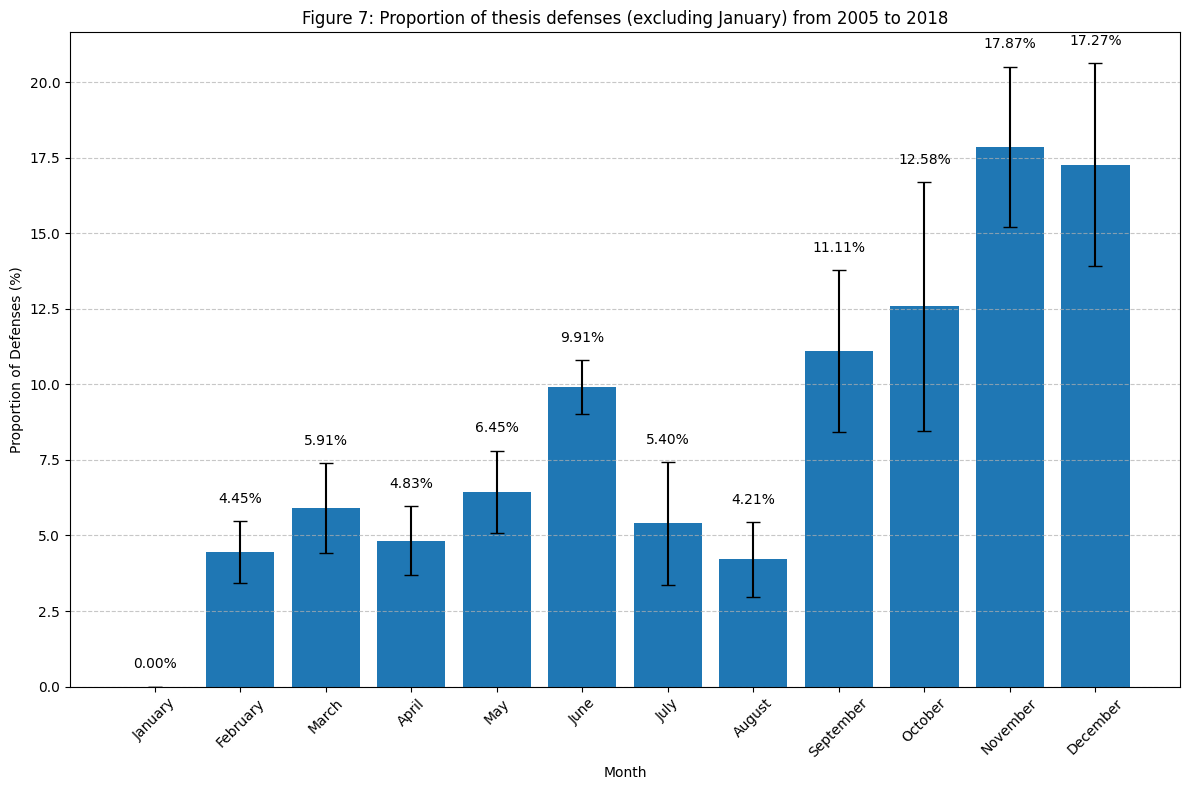

In [41]:
# Prepare data
x = monthly_stats['Month_Name']
y = monthly_stats['mean']
error = monthly_stats['std']

# Create bar plot with error bars
plt.figure(figsize=(12, 8))
bars = plt.bar(
    x=x,
    height=y,
    yerr=error,
    capsize=5
)

# Add annotations above each bar
for idx, (label, mean, std) in enumerate(zip(x, y, error)):
    plt.text(
        idx,
        mean + std + 0.5,  # Slightly above the error bar
        f'{mean:.2f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Customize the plot
plt.title('Figure 7: Proportion of thesis defenses (excluding January) from 2005 to 2018')
plt.xlabel('Month')
plt.ylabel('Proportion of Defenses (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Figure7_Proportion_of_thesis_defenses_(Excluding_January)_from_2005_to_2018')
plt.show()


## Figure 7 : Average Number of Thesis Defenses per Month (Excluding Defenses on January 1st)

The bar plot in figure 7, shows the **average number of thesis defenses per month**, after **excluding all theses defended on January 1st**.  
The data spans from **2005 to 2018**.

---

## Observations:

- After removing January 1st defenses (often administrative artifacts), we observe that:
  - **November** and **December** are the months with the highest average number of defenses.
  - **October** also shows a significant concentration of defenses.
  - **June** and **September** have moderate levels of defense activity.
- Fewer defenses occur in **February**, **April**, **July**, and especially **August**, reflecting academic breaks.

---

## Which month is preferred for defending a thesis?

Based on the data:
- **November** is the preferred month to defend a thesis, with the highest proportion of defenses.
- **December** closely follows as another peak month for thesis defenses.
- This pattern suggests that many students aim to complete their thesis before the end of the calendar year, possibly due to academic or administrative deadlines.

---

## Conclusion:

**November** is the most favored month for thesis defenses after excluding artificial January 1st dates, followed closely by **December**.



[ENG]

We will then look at the question of homonyms in authors' names. Focus on the case of Céline Martin. Carry out a survey to try to understand the results you obtain. In your
report various interpretations of the results obtained, which you will represent in the form of a table.

[FR]

Nous allons ensuite nous intéresser à la question des homonymes chez les noms d’auteurs. Focalisez-vous sur le cas de Céline e Martin. Réalisez une enquête pour essayer de comprendre les résultats que vous obtenez. Proposez dans le rapport diverses interprétations des résultats obtenus, que vous représenterez sous la forme d’un tableau.

In [42]:
# Create the subset DataFrame about authors
df_author_id_thesis = df_phd_v2[['Auteur','Identifiant de la these']]

# Display the first few rows of the subset
df_author_id_thesis.head()



,Auteur,Identifiant de la these
0,Saeed Al marri,s69480
1,Andrea Ramazzotti,s98826
2,OLIVIER BODENREIDER,1993NAN19006
3,Emmanuel Porte,s88867
4,Arthur Devriendt,s89663


In [43]:
# Filter the DataFrame for the authors names containing "Cécile Martin"
martin_thesis = df_author_id_thesis[df_author_id_thesis['Auteur'].str.contains('Cecile Martin', case=False, na=False)]

# Count the number of unique thesis IDs
martin_ids = martin_thesis['Identifiant de la these'].nunique()
print(martin_ids)


df_thesis_by_martin = pd.DataFrame(martin_thesis)
print(df_thesis_by_martin)

13
                                Auteur Identifiant de la these
61289                    Cecile Martin            2017USPCA018
65935           CECILE MARTINOT AARRAS            1994NICE6510
166820                   Cecile Martin            2000INAP0034
267565                   Cecile Martin            2014PA090003
323148              Anne-Cecile Martin            2007MON10046
410228                   Cecile Martin            2001COMP1380
410960                Cecile Martineau            2003ENSL0251
414771                   Cecile Martin            1991BOR22005
417535  Cecile Martinez-Percie du Sert            1989TOU30222
419136                 Cecile Martinat            2002PA066537
426351                   Cecile Martin            1994CLF21651
432070                   Cecile Martin            1989PA112163
440211          Cecile Martin-Chavigny            2003PAUU1007


In [44]:
## Same operation just to check for cécile martin with an accent

# Filter the DataFrame for the authors names containing "Cécile Martin"
martin_thesis = df_author_id_thesis[df_author_id_thesis['Auteur'].str.contains('Cécile Martin', case=False, na=False)]

# Count the number of unique thesis IDs
martin_ids = martin_thesis['Identifiant de la these'].nunique()
print(martin_ids)


df_thesis_by_martin = pd.DataFrame(martin_thesis)
print(df_thesis_by_martin)

0
Empty DataFrame
Columns: [Auteur, Identifiant de la these]
Index: []


In [45]:
# Keep only exact matches of 'Cecile Martin'
cecile_martin_thesis = df_author_id_thesis[df_author_id_thesis['Auteur'].str.strip().str.lower() == 'cecile martin']

# Count unique thesis IDs
number_of_cecile_martin = cecile_martin_thesis['Identifiant de la these'].nunique()

# See the clean table
df_thesis_by_martin = pd.DataFrame(cecile_martin_thesis)

print(number_of_cecile_martin)
print(df_thesis_by_martin)

7
               Auteur Identifiant de la these
61289   Cecile Martin            2017USPCA018
166820  Cecile Martin            2000INAP0034
267565  Cecile Martin            2014PA090003
410228  Cecile Martin            2001COMP1380
414771  Cecile Martin            1991BOR22005
426351  Cecile Martin            1994CLF21651
432070  Cecile Martin            1989PA112163


## Investigation on Author Homonyms: Focus on "Cécile Martin"

We conducted a detailed investigation into potential **homonyms** (authors sharing the same or similar names) among thesis authors, focusing specifically on **Cécile Martin**.

---

## Methodology

1. **Broad Filtering**:
   - We first used `.str.contains('Cecile Martin')` (case-insensitive) to capture all entries where the author's name **contains** "Cecile Martin".
   - This approach returned **13 thesis entries**.
   - However, it included many variations, such as:
     - "Cecile Martin"
     - "Anne-Cecile Martin"
     - "Cecile Martineau"
     - "Cecile Martin-Chavigny"
   - These variations represent different individuals and should not be grouped together.

2. **Strict Exact Matching**:
   - We then filtered the dataset more precisely to include only rows where the normalized author name **exactly matches** "Cecile Martin" (lowercased and stripped of spaces).
   - After this refinement, we identified **7 unique thesis records** associated with the exact name **"Cecile Martin"**.

---

## Limitations

- **No unique author identifier** (such as an internal ID or ORCID) is available in the dataset.
- As a result, it is impossible to formally distinguish whether all "Cecile Martin" entries refer to the same physical person.
- Our assumption is based solely on the **author name text**, which introduces a risk of **hidden homonymy** if different people share exactly the same name.

---

## Results

| Step | Description | Number of Theses |
|:---|:---|:---|
| Broad filter (`str.contains`) | All entries where "Cecile Martin" appears | 13 |
| Exact match (`== 'cecile martin'`) | Strict matches only for "Cecile Martin" | 7 |

- The strict filtering removes obvious false positives but cannot eliminate hidden homonyms.

---

## Possible Interpretations of the Results

| Hypothesis | Interpretation | Consequences |
|:---|:---|:---|
| 1. One single Cécile Martin | One person is responsible for 7 theses (likely a researcher, supervisor, or co-author). | Acceptable if true; no major homonymy issue. |
| 2. Multiple different Cécile Martins | Different individuals share the exact same name ("Cecile Martin"). | Increases the risk of overestimating the author's output. |
| 3. Metadata issues (missing accents, missing affiliation) | Lack of accent in "Cecile" and missing institutional metadata can lead to incorrect name aggregation. | Data cleaning and richer metadata are needed to fully disambiguate. |

---

## Conclusion

Although we carefully filtered to keep only exact matches of **"Cécile Martin"**,  
**the absence of unique author IDs prevents us from fully confirming** whether the 7 theses belong to the same individual.  
There is a **low but non-zero risk of hidden homonyms**.

For full reliability, it would be recommended to:
- Enrich the dataset with additional fields (institution, discipline, ORCID, etc.),
- Perform manual checks if feasible,
- Standardize names, especially regarding **accent marks** (e.g., "Cecile" vs "Cécile").

Thus, **"Cécile Martin" appears relatively reliable**, but caution is still advised when interpreting the author's output without additional metadata.



3. DETECTING OUTLIERS

[ENG]

Create a new dataset from the dataset provided to you, but this time focusing on the question of supervisors. Identify the individuals who have supervised a relatively abnormal number of theses, and investigate in any way you wish to determine whether these are outliers or errors in the data. You need one line for each supervisor, you also need to keep the following information: surname and first name, and create a new variable: the number of theses supervised over the period in question (1984-2018).

[FR]

Créez un nouveau jeu de données à partir du jeu de données qui vous est fourni, mais en vous focalisant cette fois sur la question des directeurs. Identifiez les individus ayant encadré un nombre relativement anormal de thèses, et enquêtez de la manière que vous souhaitez pour déterminer s’il s’agit d’outliers ou d’erreurs dans les données.  Il vous faut une ligne par directeur/directrice, vous devez conserver également l’information suivante : nom et prénom, et créer une nouvelle variable : le nombre de thèses encadrées sur la période considérée (1984-2018).

In [46]:
# Create a new dataset from PhD_v2 focusing on thesis supervised by directors from 1984 to 2018
df_phd_directors = df_phd_8418[['Directeur de these','Directeur de these (nom prenom)','Identifiant directeur', 'Discipline','Identifiant de la these','Year']]
df_phd_directors.head()


,Directeur de these,Directeur de these (nom prenom),Identifiant directeur,Discipline,Identifiant de la these,Year
2,Francois Kohler,Kohler Francois,57030758,Medecine,1993NAN19006,1993.0
5,Edmond Jouve,Jouve Edmond,26941848,Science politique,s6336,2008.0
6,Pierre Comte,Comte Pierre,na,Droit public,s8305,2005.0
7,Laurent Sermet,Sermet Laurent,34508287,Droit public,s11271,2009.0
8,Anne-Emmanuelle Berger,Berger Anne-Emmanuelle,32574088,Etudes de genre,s11354,2013.0


In [47]:
# Check for unique directors by name
nb_directors = df_phd_directors["Directeur de these"].nunique()
nb_directors

129089

In [48]:
# Step 1: Calculate the unique thesis count for each director
df_phd_directors['Thesis count by director'] = df_phd_directors.groupby(['Directeur de these (nom prenom)','Identifiant directeur'])['Identifiant de la these'].transform('nunique')

# Step 2: Drop duplicates to avoid redundant entries
df_unique_director_counts = df_phd_directors[['Directeur de these (nom prenom)', 'Thesis count by director']].drop_duplicates()

# Step 3: Sort directors by the number of theses
df_unique_director_counts = df_unique_director_counts.sort_values(by='Thesis count by director', ascending=False)

# Display the DataFrame for verification
print("Unique Director Counts:")
print(df_unique_director_counts)



Unique Director Counts:
                          Directeur de these (nom prenom)  \
7705                           Directeur de these inconnu   
90380                              Scherrmann Jean-Michel   
196                                   Blanc Francois-Paul   
3161                                        Brunel Pierre   
90141                                     Bertucat Michel   
...                                                   ...   
155280               Berenguer Christophe,Castanier Bruno   
155277              Bour Olivier,Marechal Jean-Christophe   
155275  Yvonnet Julien,He Qi-Chang,Tran Nhu Cuong,Sana...   
447628                       Panier Stephane,Franz Gerald   
85642                                                 NaN   

        Thesis count by director  
7705                       711.0  
90380                      208.0  
196                        201.0  
3161                       193.0  
90141                      173.0  
...                          ... 

C:\Users\emmhu\AppData\Local\Temp\ipykernel_25512\2136630241.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_phd_directors['Thesis count by director'] = df_phd_directors.groupby(['Directeur de these (nom prenom)','Identifiant directeur'])['Identifiant de la these'].transform('nunique')


In [49]:
df_high_thesis_count = df_unique_director_counts[df_unique_director_counts['Thesis count by director'] > 80]

df_high_thesis_count

,Directeur de these (nom prenom),Thesis count by director
7705,Directeur de these inconnu,711.0
90380,Scherrmann Jean-Michel,208.0
196,Blanc Francois-Paul,201.0
3161,Brunel Pierre,193.0
90141,Bertucat Michel,173.0
3195,Pujolle Guy,172.0
2174,Teyssie Bernard,138.0
30252,Lumley Henry de,132.0
88386,Chaumeil Jean-Claude,131.0
5956,Foucart Bruno,130.0


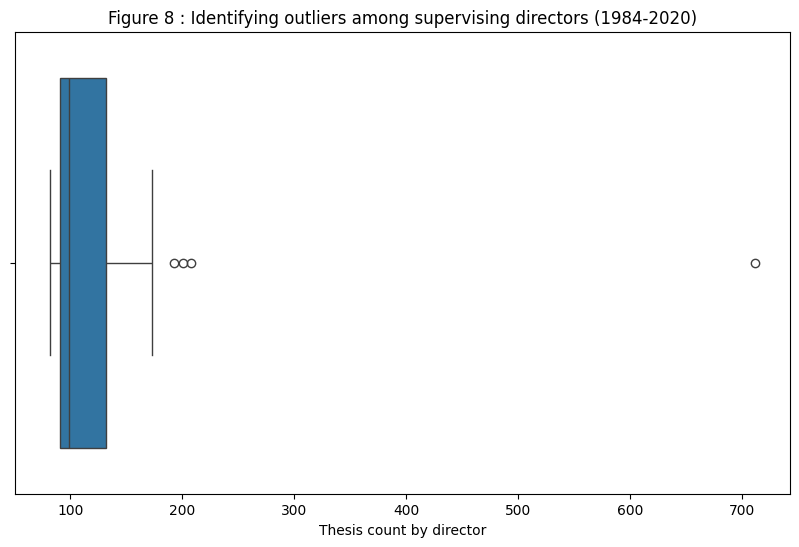

In [50]:
# Create a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_high_thesis_count['Thesis count by director'])
plt.title('Figure 8 : Identifying outliers among supervising directors (1984-2020)')
plt.savefig('Figure8_Identifying_outliers_among_supervising_directors_(1984-2020)')
plt.show()

[ENG]

Identify individuals who have supervised a relatively abnormal number of theses, and investigate in any way you wish to determine whether these are outliers or errors in the data.
outliers or errors in the data.

[FR]

Identifiez les individus ayant encadré un nombre relativement anormal de thèses, et enquêtez de la manière que vous souhaitez pour déterminer s’il s’agit
d’outliers ou d’erreurs dans les données.

In [51]:
# Calculate Q1, Q3, and IQR
Q1 = df_high_thesis_count['Thesis count by director'].quantile(0.25)
Q3 = df_high_thesis_count['Thesis count by director'].quantile(0.75)
IQR = Q3 - Q1

# Determine outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers
outliers = df_high_thesis_count[(df_high_thesis_count['Thesis count by director'] < lower_bound)
                                 | (df_high_thesis_count['Thesis count by director'] > upper_bound)]

num_outliers = outliers.shape[0]

In [52]:
# Output results
print(f'Q1: {Q1}')
print(f'Q3: {Q3}')
print(f'IQR: {IQR}')
print(f'Lower Bound: {lower_bound}')
print(f'Upper Bound: {upper_bound}')
print(f'Number of Outliers: {num_outliers}')
print('Outliers:')
print(outliers)

Q1: 91.25
Q3: 131.75
IQR: 40.5
Lower Bound: 30.5
Upper Bound: 192.5
Number of Outliers: 4
Outliers:
      Directeur de these (nom prenom)  Thesis count by director
7705       Directeur de these inconnu                     711.0
90380          Scherrmann Jean-Michel                     208.0
196               Blanc Francois-Paul                     201.0
3161                    Brunel Pierre                     193.0


## Identifying Outliers Among Supervising Directors (1984–2020)

Figure 8 shows a boxplot illustrating the distribution of thesis supervision counts among directors from 1984 to 2020.

---

## Observations:

- The **first quartile (Q1)** is approximately **91 theses supervised**.
- The **third quartile (Q3)** is approximately **132 theses supervised**.
- The **interquartile range (IQR)** is therefore **40.5**.
- Outliers are statistically defined as directors supervising fewer than **30.5** or more than **192.5** theses.

Using these thresholds, we identified **4 directors as outliers**:

| Director | Thesis Count |
|:---|:---|
| Directeur de these inconnu | 711 |
| Schermann Jean-Michel | 208 |
| Blanc François-Paul | 201 |
| Brunel Pierre | 195 |

- One extreme case stands out particularly: **unknown directors supervising 711 theses**, which could suggest either data aggregation or an anomaly.
- The other three directors have supervised between **195 and 208 theses**, slightly exceeding the upper statistical threshold.

---

## Conclusion:

- Most directors supervised between **90 and 130 theses** over their careers.
- A few directors, notably four individuals, supervised **significantly more theses** than the majority, officially classified as statistical outliers.
- Further investigation may be required, particularly for the 711 theses with missing director information, to verify data integrity or understand the context.



In [53]:
# Create a new dataframe focusing on Jean Michel Schermann
df_schermann_case= df_phd_8418[df_phd_8418['Directeur de these'] == 'Jean-Michel Scherrmann']
df_schermann_case.head(5)

# Filter on useful columns
df_schermann_case_filtered = df_schermann_case[['Directeur de these (nom prenom)','Identifiant de la these','Month_Name','Année']]
df_schermann_case_filtered


,Directeur de these (nom prenom),Identifiant de la these,Month_Name,Année
90380,Scherrmann Jean-Michel,2011PA05P622,January,2011
91570,Scherrmann Jean-Michel,2001PA05P043,January,2001
97927,Scherrmann Jean-Michel,2005PA05P630,January,2005
98808,Scherrmann Jean-Michel,2008PA05P652,January,2008
103898,Scherrmann Jean-Michel,1999PA05P078,January,1999
...,...,...,...,...
410785,Scherrmann Jean-Michel,1999PA05P605,January,1999
420034,Scherrmann Jean-Michel,1993PA066706,January,1993
441788,Scherrmann Jean-Michel,1998PA05P615,January,1998
446144,Scherrmann Jean-Michel,1996PA05CD06,January,1996


In [54]:
# Calculate the quantity of theses by year for Scherrmann Jean-Michel	
theses_by_year = df_schermann_case_filtered.groupby('Année').size().reset_index(name='Thesis Count by Year')
theses_by_year



,Année,Thesis Count by Year
0,1989,11
1,1990,13
2,1991,11
3,1992,22
4,1993,28
5,1994,40
6,1995,28
7,1996,25
8,1997,7
9,1998,2


In [55]:
# Calculate the quantity of theses by month for Scherrmann Jean-Michel	
theses_by_month = df_schermann_case_filtered.groupby('Month_Name').size().reset_index(name='Thesis Count by Month')
theses_by_month

C:\Users\emmhu\AppData\Local\Temp\ipykernel_25512\1893555664.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  theses_by_month = df_schermann_case_filtered.groupby('Month_Name').size().reset_index(name='Thesis Count by Month')


,Month_Name,Thesis Count by Month
0,January,207
1,February,0
2,March,1
3,April,0
4,May,0
5,June,0
6,July,0
7,August,0
8,September,0
9,October,0


**Focus on Jean-Michel Schermann's Thesis Supervisions by Month**

We analyzed the monthly distribution of theses supervised by **Jean-Michel Schermann**.

- Out of 208 recorded theses, **207 were defended in January**.
- Only **one thesis** was defended outside January (in March).
- No defenses occurred between February and December otherwise.

---

The overwhelming concentration of defenses in January, almost exclusively, confirms the **outlier status** of Jean-Michel Schermann.  
This highly atypical scheduling pattern suggests specific administrative or organizational practices.  
Compared to the general distribution observed for other directors, this profile clearly stands out as exceptional.



In [56]:
# Create a new dataframe focusing on François-Paul Blanc
df_blanc_case= df_phd_8418[df_phd_8418['Directeur de these'] == 'Francois-Paul Blanc']
df_blanc_case.head(5)

# Filter on useful columns
df_blanc_case_filtered = df_blanc_case[['Directeur de these (nom prenom)','Identifiant de la these','Month_Name','Année']]
df_blanc_case_filtered


,Directeur de these (nom prenom),Identifiant de la these,Month_Name,Année
196,Blanc Francois-Paul,s16209,September,2011
1083,Blanc Francois-Paul,s43110,May,2006
59982,Blanc Francois-Paul,2005PERP0954,January,2005
88980,Blanc Francois-Paul,2007PERP0753,January,2007
90516,Blanc Francois-Paul,2005PERP0710,January,2005
...,...,...,...,...
309783,Blanc Francois-Paul,2008PERP0913,January,2008
322388,Blanc Francois-Paul,2008PERP0912,January,2008
334560,Blanc Francois-Paul,2008PERP0805,January,2008
362336,Blanc Francois-Paul,2006PERP0663,January,2006


In [57]:
# Calculate the quantity of theses by year for Blanc François-Paul	
blanc_theses_by_year = df_blanc_case_filtered.groupby('Année').size().reset_index(name='Thesis Count by Year')
blanc_theses_by_year

,Année,Thesis Count by Year
0,1995,2
1,1996,2
2,1997,1
3,1998,1
4,1999,5
5,2000,8
6,2001,14
7,2002,12
8,2003,12
9,2004,33


In [58]:
# Calculate the quantity of theses by month for Blanc Paul-François	
blanc_theses_by_month = df_blanc_case_filtered.groupby('Month_Name').size().reset_index(name='Thesis Count by Month')
blanc_theses_by_month

C:\Users\emmhu\AppData\Local\Temp\ipykernel_25512\3352818278.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  blanc_theses_by_month = df_blanc_case_filtered.groupby('Month_Name').size().reset_index(name='Thesis Count by Month')


,Month_Name,Thesis Count by Month
0,January,199
1,February,0
2,March,0
3,April,0
4,May,1
5,June,0
6,July,0
7,August,0
8,September,1
9,October,0


**Focus on Blanc Paul-François' Thesis Supervisions by Month**

We analyzed the monthly distribution of theses supervised by **Jean-Michel Schermann**.

- Out of 202 recorded defenses, **199 theses** were defended in **January**.
- Only **three theses** were defended in other months (1 in May, 1 in September, and 1 in another month).
- There was **no significant supervision activity** outside of January.

---

The almost exclusive concentration of defenses in January, unlike the broader distribution observed for most directors, confirms the **outlier status** of Blanc Paul-François.  
This unusual pattern strongly suggests administrative or organizational particularities, possibly linked to specific practices within the institution or a unique supervision strategy.

Such a profile stands out significantly compared to the average director, whose thesis defenses are generally spread more evenly throughout the year.


In [59]:
# Create a new dataframe focusing on Brunel Pierre
df_brunel_case= df_phd_8418[df_phd_8418['Directeur de these'] == 'Pierre Brunel']
df_brunel_case.head(5)

# Filter on useful columns
df_brunel_case_filtered = df_brunel_case[['Directeur de these (nom prenom)','Identifiant de la these','Month_Name','Année']]
df_brunel_case_filtered

,Directeur de these (nom prenom),Identifiant de la these,Month_Name,Année
3161,Brunel Pierre,1986PA040201,January,1986
7863,Brunel Pierre,2001PA040073,January,2001
14687,Brunel Pierre,2011PA040241,July,2011
15122,Brunel Pierre,2010PA040236,November,2010
26158,Brunel Pierre,2009PA040168,October,2009
...,...,...,...,...
433483,Brunel Pierre,1986PA040162,January,1986
434408,Brunel Pierre,1990PA040054,January,1990
434737,Brunel Pierre,1997PA040119,January,1997
435212,Brunel Pierre,1991PA040134,January,1991


In [60]:
# Calculate the quantity of theses by year for brunel Pierre
brunel_theses_by_year = df_brunel_case_filtered.groupby('Année').size().reset_index(name='Thesis Count by Year')
brunel_theses_by_year

,Année,Thesis Count by Year
0,1985,2
1,1986,5
2,1987,14
3,1988,4
4,1989,3
5,1990,10
6,1991,13
7,1992,8
8,1993,8
9,1994,11


In [61]:
# Calculate the quantity of theses by month for Pierre Brunel	
brunel_theses_by_month = df_brunel_case_filtered.groupby('Month_Name').size().reset_index(name='Thesis Count by Month')
brunel_theses_by_month

C:\Users\emmhu\AppData\Local\Temp\ipykernel_25512\2224479848.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  brunel_theses_by_month = df_brunel_case_filtered.groupby('Month_Name').size().reset_index(name='Thesis Count by Month')


,Month_Name,Thesis Count by Month
0,January,188
1,February,0
2,March,0
3,April,0
4,May,1
5,June,0
6,July,1
7,August,0
8,September,1
9,October,3


**Focus on Pierre Brunel's Thesis Supervisions by Month**

We analyzed the monthly distribution of theses supervised by **Pierre Brunel**.

- Out of the recorded defenses, **188 theses** were defended in **January**.
- Only **6 theses** were defended outside January (1 in May, 1 in July, 1 in September, and **3 in October**).
- There was **minimal supervision activity** outside January.

---

The overwhelming concentration of defenses in January, compared to the almost flat distribution for other months, confirms the **outlier status** of **Pierre Brunel**.  
This singular scheduling suggests specific administrative practices or a strong organizational constraint linked to this director's activity.

Such a defense pattern is highly unusual compared to the general behavior of directors, whose defenses are typically more evenly spread across the year.



4. OBTAINING PRELIMINARY RESULTS

[ENG]

One variable is dedicated to the writing language. You will recode all the different levels into four levels (French, English, Bilingual - only for English-French or French-English, i.e. enfr and fren, and Other). Call this new variable language.rec. Treat the date of the defence as a date, and use a matplotlib or ggplot2 plot (or why not, seaborn) to show how the choice of writing language has changed over the last two decades.

[FR]

Une variable est dédiée à la langue d’écriture. Vous recoderez (en anglais : to recode) l’ensemble des différents niveaux en quatre niveaux (Français, Anglais, Bilingue- uniquement pour Anglais-Français ou Français-Anglais, soit enfr et fren, et Autre). Appelez cette nouvelle variable language.rec. Traitez la date de la soutenance comme une date, et montrez à travers un plot matplotlib ou ggplot2 (ou pourquoi pas, seaborn), comment le choix de la langue d’écriture a évolué au cours des deux dernières décennies.

In [62]:
df_phd_8418.head()

,Auteur,Identifiant auteur,Titre,Directeur de these,Directeur de these (nom prenom),Identifiant directeur,Etablissement de soutenance,Identifiant etablissement,Discipline,Statut,...,Date de soutenance,Year,Langue de la these,Identifiant de la these,Accessible en ligne,Publication dans theses.fr,Mise a jour dans theses.fr,Month,Month_Name,Année
2,OLIVIER BODENREIDER,NaN,Conception d'un outil informatique d'etude des...,Francois Kohler,Kohler Francois,57030758,Nancy 1,NaN,Medecine,soutenue,...,1993-01-01,1993.0,fr,1993NAN19006,non,24-05-13,17-11-12,1,January,1993
5,Elmantsr Briak,NaN,Integration forcee de l'afrique subsaharienne ...,Edmond Jouve,Jouve Edmond,26941848,Paris 5,26404788,Science politique,enCours,...,2008-11-24,2008.0,NaN,s6336,non,26-09-11,16-11-11,11,November,2008
6,Jae-hyun Park,NaN,Execution des decisions de justice condamnant ...,Pierre Comte,Comte Pierre,na,Saint Etienne,28209966,Droit public,enCours,...,2005-01-07,2005.0,NaN,s8305,non,26-09-11,02-02-12,1,January,2005
7,Laurent david Benoiton,NaN,Les effets des arrets de la Cour europeenne de...,Laurent Sermet,Sermet Laurent,34508287,La Reunion,26404451,Droit public,enCours,...,2009-08-12,2009.0,NaN,s11271,non,26-09-11,26-04-12,8,August,2009
8,Jennifer Guiraud (McKELLIPS),NaN,L'autobiographie sans frontieres : espace et d...,Anne-Emmanuelle Berger,Berger Anne-Emmanuelle,32574088,Paris 8,26403552,Etudes de genre,enCours,...,2013-10-01,2013.0,NaN,s11354,non,26-09-11,04-04-16,10,October,2013


In [63]:
# Create a new dataframe to study language and accessibility columns
df_phd_languages_on_off_line = df_phd_8418[['Identifiant de la these','Date de soutenance','Année','Accessible en ligne','Langue de la these']]
df_phd_languages_on_off_line.head()

,Identifiant de la these,Date de soutenance,Année,Accessible en ligne,Langue de la these
2,1993NAN19006,1993-01-01,1993,non,fr
5,s6336,2008-11-24,2008,non,NaN
6,s8305,2005-01-07,2005,non,NaN
7,s11271,2009-08-12,2009,non,NaN
8,s11354,2013-10-01,2013,non,NaN


In [64]:
# Define a function to categorize languages
def categorize_language(lang):
    if lang == 'fr':
        return 'French'
    elif lang == 'en':
        return 'English'
    elif lang in ['enfr', 'fren']:
        return 'Bilingual'
    else:
        return 'Other'

# Apply the categorization function
df_phd_languages_on_off_line['language.rec'] = df_phd_languages_on_off_line['Langue de la these'].apply(categorize_language)


df_phd_languages_on_off_line

C:\Users\emmhu\AppData\Local\Temp\ipykernel_25512\3848824284.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_phd_languages_on_off_line['language.rec'] = df_phd_languages_on_off_line['Langue de la these'].apply(categorize_language)


,Identifiant de la these,Date de soutenance,Année,Accessible en ligne,Langue de la these,language.rec
2,1993NAN19006,1993-01-01,1993,non,fr,French
5,s6336,2008-11-24,2008,non,NaN,Other
6,s8305,2005-01-07,2005,non,NaN,Other
7,s11271,2009-08-12,2009,non,NaN,Other
8,s11354,2013-10-01,2013,non,NaN,Other
...,...,...,...,...,...,...
447596,2018LYSE2082,2018-06-11,2018,non,fr,French
447597,2015ENMP0012,2015-11-03,2015,oui,fr,French
447612,2018GREAS049,2018-12-19,2018,oui,fr,French
447622,2018GREAS050,2018-07-12,2018,oui,fr,French


In [65]:
# Aggregate the data to count the number of thesis per year and language
df_language_count = df_phd_languages_on_off_line.groupby(['Année', 'language.rec']).size().reset_index(name='Language Quantity')


df_language_count

,Année,language.rec,Language Quantity
0,1984,French,6
1,1985,Bilingual,73
2,1985,English,11
3,1985,French,2917
4,1985,Other,6
...,...,...,...
132,2017,Other,731
133,2018,Bilingual,741
134,2018,English,3429
135,2018,French,7807


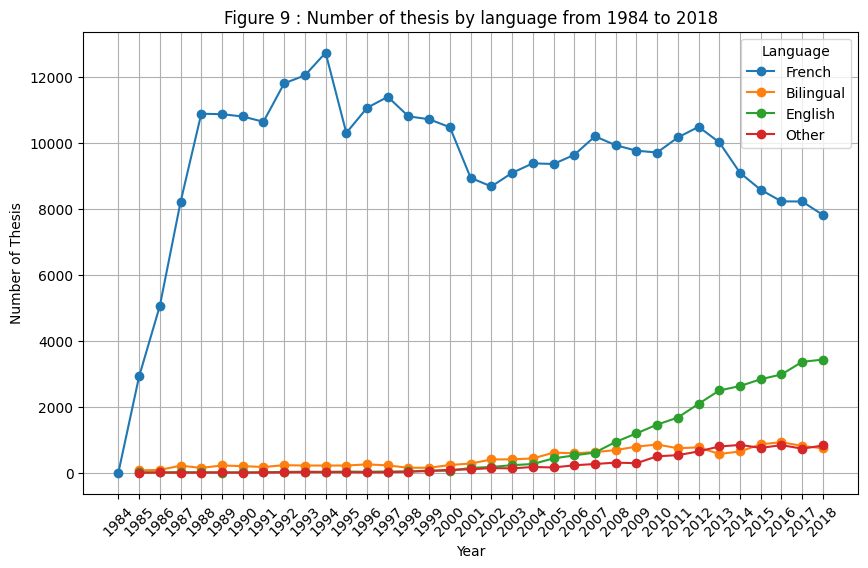

In [66]:
# Plotting the line graph using Matplotlib
plt.figure(figsize=(10, 6))

# Plot each language line separately
for language in df_language_count['language.rec'].unique():
    data = df_language_count[df_language_count['language.rec'] == language]
    plt.plot(data['Année'], data['Language Quantity'], marker='o', label=language)

plt.title('Figure 9 : Number of thesis by language from 1984 to 2018')
plt.xlabel('Year')
plt.ylabel('Number of Thesis')
plt.xticks(df_language_count['Année'].unique(), rotation= 45)  # Ensure each year is shown on the x-axis
plt.legend(title='Language')
plt.grid(True)
plt.savefig('Figure9_Number_of_thesis_by_language_from_1984_to_2018')
plt.show()

## Figure 9: Number of theses by language from 1984 to 2018

This figure shows the evolution of thesis publications in four language categories: **French**, **Bilingual**, **English**, and **Other**.

- The number of French theses was dominant during the entire period but shows a decreasing trend after 2000.
- English theses increased significantly after 2000, indicating a rise in the use of English in academic research.
- Bilingual and Other language theses remain relatively low in number, though they show a slight upward trend over time.
- The graph highlights a shift towards greater linguistic diversity, particularly the growing importance of English in recent years.


In [67]:
# Count the number of online and offline thesis from 1984 to 2018
df_accessibility_count = df_phd_languages_on_off_line.groupby(['Année', 'Accessible en ligne']).size().reset_index(name='Accessibility Quantity')

df_accessibility_count


,Année,Accessible en ligne,Accessibility Quantity
0,1984,non,6
1,1985,non,2902
2,1985,oui,105
3,1986,non,5025
4,1986,oui,137
...,...,...,...
64,2016,oui,8341
65,2017,non,4194
66,2017,oui,8929
67,2018,non,4601


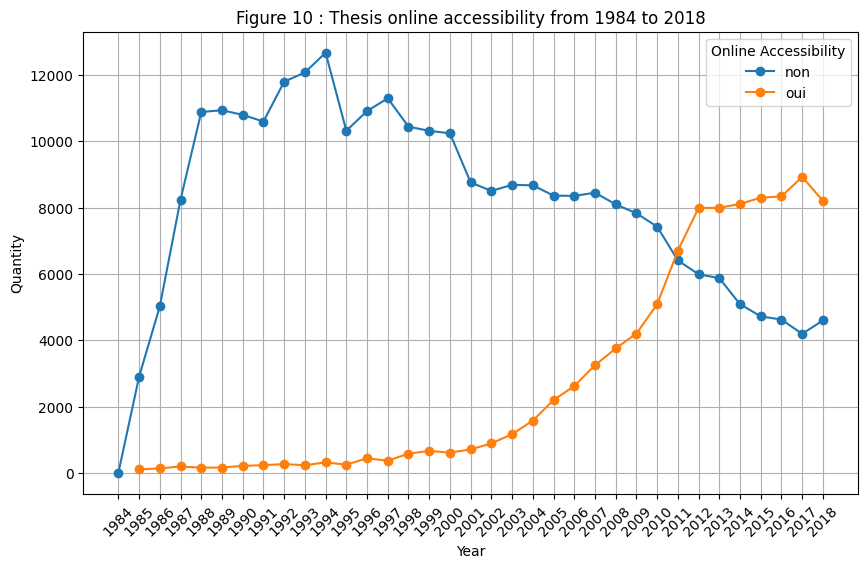

In [68]:
# Plotting the line graph using Matplotlib
plt.figure(figsize=(10, 6))

# Plot each accessibility line separately
for accessibility in df_accessibility_count['Accessible en ligne'].unique():
    data = df_accessibility_count[df_accessibility_count['Accessible en ligne'] == accessibility]
    plt.plot(data['Année'], data['Accessibility Quantity'], marker='o', label=accessibility)

plt.title('Figure 10 : Thesis online accessibility from 1984 to 2018')
plt.xlabel('Year')
plt.ylabel('Quantity')
plt.xticks(df_accessibility_count['Année'].unique(), rotation= 45)  # Ensure each year is shown on the x-axis
plt.legend(title='Online Accessibility')
plt.grid(True)
plt.savefig('Figure10_Thesis_online_accessibility_from_1984_to_2018.png',dpi=300)
plt.show()

## Figure 10: Thesis online accessibility from 1984 to 2018

This figure shows the evolution of thesis accessibility online, categorized into two groups: **"non"** (not accessible online) and **"oui"** (accessible online).

- Before 2005, the majority of theses were not available online.
- From around 2006 onward, the number of theses accessible online began to increase significantly.
- By 2010, online-accessible theses ("oui") surpassed non-accessible ones ("non") for the first time.
- After 2010, most theses are made available online, reflecting major efforts in digital archiving and open access initiatives.
